<a href="https://colab.research.google.com/github/Iddhie/MSc-Data-Science-Research/blob/main/MScDS_Bull2_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Analysis for the Research Titled: Uniswap User Profiling via Deep Clustering: Behavioral Patterns and Economic Implications for Decentralized Exchanges - Bear Market Phase**

This Google Colab Notebook carries out the data importing, PDA, EDA, clustering algorithm application and intra-cluster analysis for the bear market regime data.

**Data Source:**  All of the data imported through Google Drive into this Notebook were extracted from the Google BigQuery Ethereum Cryptocurrency dataset using the BigQuery Studio platform.

**Objectives:**
1.	To apply feature engineering techniques to aggregate wallet activity data into a format suitable for behavioral clustering and temporal comparison.
2.	To perform clustering analysis to identify distinct user groups based on wallet behavior in each market phase.
3.	To determine the key features influencing wallet cluster formation and differentiation.

**Contents:**
1. Manual K-Means Clustering Application
2. Classical Clustering Algorithms Application
- 2.1 K-Means Clustering
- 2.2 Agglomerative Clustering
- 2.3 GMM Clustering
- 2.4 DBSCAN Clustering
3. PCA Application
- 3.1 K-Means Clustering
- 3.2 Agglomerative Clustering
- 3.3 GMM Clustering
- 3.4 DBSCAN Clustering
4. Deep-Learning Based Clustering
- 4.1 Variation Autoencoder Model
  - VAE + K-Means Clustering
  - VAE + Agglomerative Clustering
  - VAE + GMM Clustering
  - VAE + DBSCAN Clustering
- 4.2 Deep InfoMax Clustering
  - Deep InfoMax + K-Means
  - Intra-Cluster Analysis
- 4.3 Deep Embedded Clustering
- 4.4 Self-Organizing Map Clustering

## **I. Importing Relevant Libraries for the Analysis**

In [ ]:
pip install pytorch_lightning

In [ ]:
pip install minisom

In [ ]:
from datetime import datetime
import requests
import pandas as pd
import numpy as np
import seaborn as sns
import math
import matplotlib.pyplot as plt
import minisom
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from yellowbrick.cluster import KElbowVisualizer
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from tabulate import tabulate
from scipy.stats import kruskal, chi2_contingency
from google.colab import drive, files
from pandas import json_normalize
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import dendrogram, linkage
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Lambda, BatchNormalization, LeakyReLU, Layer
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.losses import mse
import tensorflow.keras.backend as K
from keras.losses import KLDivergence
from keras.optimizers import SGD, Adam
import matplotlib.patches as mpatches
from keras.losses import MeanSquaredError
import torch
import torch.nn as nn
import scipy.stats as stats
from scipy.stats import shapiro, skew, kurtosis, probplot
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.ensemble import RandomForestClassifier
from scipy.spatial.distance import pdist, squareform
import networkx as nx
from datetime import datetime
from collections import Counter
from google.colab import files
import os, glob, io
import pytorch_lightning as pl

%matplotlib inline

## **Data Importing and Initial Data Analysis**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **Dataset Aggregation and Feature Engineering**


In [1]:
BASE_DIR = '/content/drive/MyDrive/Bear/'

def _find_in_dir(name):
    variants = [
        name,
        name.replace(' ', '_'),
        name.replace(' ', ''),
        name.lower(),
        name.lower().replace(' ', '_'),
        name.lower().replace(' ', '')
    ]
    for v in variants:
        p = os.path.join(BASE_DIR, v)
        if os.path.exists(p):
            return p
        matches = glob.glob(os.path.join(BASE_DIR, f"*{os.path.basename(v)}*"))
        for m in matches:
            if os.path.isfile(m):
                return m
    return None

def load_csv_if_present(name, parse_dates=None):
    path = _find_in_dir(name)
    if path:
        print(f"Loading from Drive: {os.path.basename(path)}")
        return pd.read_csv(path, parse_dates=parse_dates)
    print(f"Note: '{name}' not found in Drive (skipping).")
    return None

df_tx   = load_csv_if_present('transactions.csv', parse_dates=None)
df_tok  = load_csv_if_present('token transfers.csv', parse_dates=None)
df_trc  = load_csv_if_present('traces.csv', parse_dates=None)
df_ctr  = load_csv_if_present('contracts.csv', parse_dates=None)
df_miner= load_csv_if_present('miner flag.csv', parse_dates=None)
df_wadd = load_csv_if_present('wallet address.csv', parse_dates=None)

print("\nLoaded:")
for n, df in {
    'transactions.csv': df_tx,
    'token transfers.csv': df_tok,
    'traces.csv': df_trc,
    'contracts.csv': df_ctr,
    'miner flag.csv': df_miner,
    'wallet address.csv': df_wadd
}.items():
    print(f"  {n}: {'OK' if df is not None else 'MISSING'}")

Loading from Drive: transactions.csv


NameError: name 'pd' is not defined

In [ ]:
ts_col_tx = 'block_timestamp'
ts_col_tok = 'block_timestamp'
ts_col_trc = 'block_timestamp'
ts_col_ctr = 'deploy_timestamp'

df_tx[ts_col_tx] = pd.to_datetime(df_tx[ts_col_tx])
df_tok[ts_col_tok] = pd.to_datetime(df_tok[ts_col_tok])
df_trc[ts_col_trc] = pd.to_datetime(df_trc[ts_col_trc])
df_ctr[ts_col_ctr] = pd.to_datetime(df_ctr[ts_col_ctr])

period = 'M'

tx_counts = df_tx.groupby(pd.Grouper(key=ts_col_tx, freq=period)).size().reset_index(name='total_transactions')
tok_counts = df_tok.groupby(pd.Grouper(key=ts_col_tok, freq=period)).size().reset_index(name='token_transfers')
trc_counts = df_trc.groupby(pd.Grouper(key=ts_col_trc, freq=period)).size().reset_index(name='traces')
ctr_counts = df_ctr.groupby(pd.Grouper(key=ts_col_ctr, freq=period)).size().reset_index(name='contracts_deployed')

summary = tx_counts.merge(tok_counts, left_on=ts_col_tx, right_on=ts_col_tok, how='outer') \
                   .merge(trc_counts, left_on=ts_col_tx, right_on=ts_col_trc, how='outer') \
                   .merge(ctr_counts, left_on=ts_col_tx, right_on=ts_col_ctr, how='outer')

summary = summary.rename(columns={ts_col_tx: 'period'})[['period', 'total_transactions', 'token_transfers', 'traces', 'contracts_deployed']]

summary = summary.fillna(0).sort_values('period').reset_index(drop=True)

summary

In [ ]:
# === Helpers ===
def norm_addr(x):
    if pd.isna(x): return None
    return str(x).strip().lower()

def robust_agg(series, fn):
    series = pd.to_numeric(series, errors='coerce').dropna()
    if series.empty: return np.nan
    return getattr(series, fn)()

def shannon_entropy(series_counts):
    total = sum(series_counts)
    if total == 0: return 0.0
    probs = [c / total for c in series_counts if c > 0]
    return -sum(p * math.log(p, 2) for p in probs)

wallet_feats = {}
def ensure_wallet(addr):
    if addr not in wallet_feats:
        wallet_feats[addr] = {}

# === Force datetime for any block_timestamp ===
for df in [df_tx, df_tok, df_trc]:
    if df is not None and 'block_timestamp' in df.columns:
        df['block_timestamp'] = pd.to_datetime(df['block_timestamp'], errors='coerce')

# === 1. Transactions ===
if df_tx is not None:
    df_tx['from_address'] = df_tx['from_address'].map(norm_addr)
    df_tx['to_address'] = df_tx['to_address'].map(norm_addr)
    if df_tx['value'].median() > 1e10:
        df_tx['value'] /= 1e18

    for addr, sub in df_tx.groupby('from_address'):
        ensure_wallet(addr)
        w = wallet_feats[addr]
        w['tx_count_out'] = sub.shape[0]
        w['tx_value_out_sum'] = robust_agg(sub['value'], 'sum')
        w['tx_value_out_mean'] = robust_agg(sub['value'], 'mean')
        w['gas_price_mean'] = robust_agg(sub.get('gas_price', np.nan), 'mean')
        w['gas_used_sum'] = robust_agg(sub.get('gas', np.nan), 'sum')
        w['max_tx_value_out'] = robust_agg(sub['value'], 'max')
        w['min_tx_value_out'] = robust_agg(sub['value'], 'min')

        sub_times = sub['block_timestamp'].dropna().sort_values()
        w['active_days_out'] = sub_times.dt.date.nunique()
        w['avg_tx_per_day_out'] = sub.shape[0] / max(w['active_days_out'], 1)
        w['mean_tx_interval_out'] = np.mean(np.diff(sub_times.values).astype('timedelta64[s]').astype(float)) if len(sub_times) > 1 else np.nan

    for addr, sub in df_tx.groupby('to_address'):
        ensure_wallet(addr)
        w = wallet_feats[addr]
        w['tx_count_in'] = sub.shape[0]
        w['tx_value_in_sum'] = robust_agg(sub['value'], 'sum')
        w['tx_value_in_mean'] = robust_agg(sub['value'], 'mean')
        w['max_tx_value_in'] = robust_agg(sub['value'], 'max')
        w['min_tx_value_in'] = robust_agg(sub['value'], 'min')
        sub_times = sub['block_timestamp'].dropna().sort_values()
        w['active_days_in'] = sub_times.dt.date.nunique()

# === 2. Token Transfers ===
if df_tok is not None:
    df_tok['from_address'] = df_tok['from_address'].map(norm_addr)
    df_tok['to_address'] = df_tok['to_address'].map(norm_addr)

    for addr, sub in df_tok.groupby('from_address'):
        ensure_wallet(addr)
        w = wallet_feats[addr]
        w['tok_count_out'] = sub.shape[0]
        w['tok_unique_out'] = sub['token_address'].nunique()
        w['tok_entropy_out'] = shannon_entropy(Counter(sub['token_address']).values())

    for addr, sub in df_tok.groupby('to_address'):
        ensure_wallet(addr)
        w = wallet_feats[addr]
        w['tok_count_in'] = sub.shape[0]
        w['tok_unique_in'] = sub['token_address'].nunique()
        w['tok_entropy_in'] = shannon_entropy(Counter(sub['token_address']).values())

    if 'token_symbol' in df_tok.columns:
        df_tok['token_symbol'] = df_tok['token_symbol'].astype(str).str.upper()
        stablecoins = {'USDT','USDC','DAI','BUSD','TUSD','PAX','GUSD'}
        for addr, sub in df_tok.groupby('from_address'):
            ensure_wallet(addr)
            w = wallet_feats[addr]
            w['stablecoin_ratio_out'] = np.mean(sub['token_symbol'].isin(stablecoins))
        for addr, sub in df_tok.groupby('to_address'):
            ensure_wallet(addr)
            w = wallet_feats[addr]
            w['stablecoin_ratio_in'] = np.mean(sub['token_symbol'].isin(stablecoins))

# === 3. Traces ===
if df_trc is not None:
    df_trc['from_address'] = df_trc['from_address'].map(norm_addr)
    df_trc['to_address'] = df_trc['to_address'].map(norm_addr)
    for addr, sub in df_trc.groupby('from_address'):
        ensure_wallet(addr)
        wallet_feats[addr]['trace_count_out'] = sub.shape[0]
    for addr, sub in df_trc.groupby('to_address'):
        ensure_wallet(addr)
        wallet_feats[addr]['trace_count_in'] = sub.shape[0]

# === 4. Contract & Miner Flags ===
if df_ctr is not None:
    if 'wallet_address' in df_ctr.columns:
        df_ctr['wallet_address'] = df_ctr['wallet_address'].map(norm_addr)
        for addr in df_ctr['wallet_address']:
            ensure_wallet(addr)
            wallet_feats[addr]['is_contract'] = 1
    elif 'address' in df_ctr.columns:
        df_ctr['address'] = df_ctr['address'].map(norm_addr)
        for addr in df_ctr['address']:
            ensure_wallet(addr)
            wallet_feats[addr]['is_contract'] = 1

if df_miner is not None:
    if 'wallet_address' in df_miner.columns:
        df_miner['wallet_address'] = df_miner['wallet_address'].map(norm_addr)
        for addr, flag in zip(df_miner['wallet_address'], df_miner['is_miner']):
            ensure_wallet(addr)
            wallet_feats[addr]['is_miner'] = int(flag)
    elif 'address' in df_miner.columns:
        df_miner['address'] = df_miner['address'].map(norm_addr)
        for addr, flag in zip(df_miner['address'], df_miner['is_miner']):
            ensure_wallet(addr)
            wallet_feats[addr]['is_miner'] = int(flag)

# === 5. Network Centrality ===
G = nx.DiGraph()

if df_tx is not None:
    tx_edges = df_tx[['from_address', 'to_address']].dropna()
    G.add_edges_from(zip(tx_edges['from_address'], tx_edges['to_address']))

if df_tok is not None:
    tok_edges = df_tok[['from_address', 'to_address']].dropna()
    G.add_edges_from(zip(tok_edges['from_address'], tok_edges['to_address']))

deg_centrality = nx.degree_centrality(G)
bet_centrality = nx.betweenness_centrality(G, k=min(500, len(G)))
in_deg = dict(G.in_degree())
out_deg = dict(G.out_degree())

for addr in set(deg_centrality):
    ensure_wallet(addr)
    w = wallet_feats[addr]
    w['in_degree'] = in_deg.get(addr, 0)
    w['out_degree'] = out_deg.get(addr, 0)
    w['deg_centrality'] = deg_centrality[addr]
    w['betweenness'] = bet_centrality[addr]

# === 6. Assemble final DataFrame ===
feat_df = pd.DataFrame.from_dict(wallet_feats, orient='index').reset_index().rename(columns={'index': 'address'})

if df_wadd is not None:
    if 'wallet_address' in df_wadd.columns:
        df_wadd = df_wadd.rename(columns={'wallet_address': 'address'})
    elif 'address' not in df_wadd.columns:
        raise ValueError("No wallet address column found in wallet address.csv")
    feat_df = df_wadd[['address']].drop_duplicates().merge(feat_df, on='address', how='left')

count_like = [c for c in feat_df.columns if 'count' in c or c.startswith('is_')]
feat_df[count_like] = feat_df[count_like].fillna(0)
feat_df.fillna(0, inplace=True)

# === 7. Save ===
out_path = os.path.join(BASE_DIR, 'wallet_features.csv')
feat_df.to_csv(out_path, index=False)
print(f"✅ Saved {feat_df.shape[1]-1} features for {feat_df.shape[0]} wallets to {out_path}")

### **Features:**
We constructed a wallet-level feature set from Ethereum on-chain data (transactions, token transfers, contract deployments, and miner flags).
The dataset contains 19,575 unique wallet addresses and 31 features describing transactional behavior, token activity, temporal patterns, and network position.
Feature Categories

Transaction Activity (Outbound & Inbound)

 - tx_count_out, tx_count_in – Number of transactions sent/received.

 - tx_value_out_sum, tx_value_in_sum – Total value of ETH sent/received.

 - tx_value_out_mean, tx_value_in_mean – Average ETH value per transaction.

 - max_tx_value_out, max_tx_value_in – Largest single transaction value.

 - min_tx_value_out, min_tx_value_in – Smallest single transaction value.

Gas Usage (Outbound)

-  gas_price_mean – Average gas price paid.

- gas_used_sum – Total gas consumed.

Temporal Activity

- active_days_out, active_days_in – Number of days active sending/receiving.

- avg_tx_per_day_out – Average number of outbound transactions per active day.

- mean_tx_interval_out – Mean time between outbound transactions.

Token Transfer Metrics

- tok_count_out, tok_count_in – Number of tokens sent/received.

- tok_unique_out, tok_unique_in – Number of distinct token types sent/received.

- tok_entropy_out, tok_entropy_in – Diversity of token interactions (Shannon entropy).

Trace Counts (Contract Calls)

- trace_count_out, trace_count_in – Outbound/inbound trace calls.

Entity Flags

- is_contract – Whether the wallet has deployed contract addresses.

- is_miner – Whether the wallet belongs to a miner.

Network Centrality (Graph Features)

- in_degree, out_degree – Number of unique counterparties in/out.

- deg_centrality – Degree centrality score.

- betweenness – Betweenness centrality score.



In [ ]:
path='/content/drive/MyDrive/Bull/wallet_features.csv'
df=pd.read_csv(path)
print("Rows, cols:", df.shape)

df.head()

df.info()

df.describe().T

Rows, cols: (19575, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19575 entries, 0 to 19574
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   address               19575 non-null  object 
 1   tx_count_out          19575 non-null  float64
 2   tx_value_out_sum      19575 non-null  float64
 3   tx_value_out_mean     19575 non-null  float64
 4   gas_price_mean        19575 non-null  float64
 5   gas_used_sum          19575 non-null  float64
 6   max_tx_value_out      19575 non-null  float64
 7   min_tx_value_out      19575 non-null  float64
 8   active_days_out       19575 non-null  float64
 9   avg_tx_per_day_out    19575 non-null  float64
 10  mean_tx_interval_out  19575 non-null  float64
 11  tok_count_out         19575 non-null  float64
 12  tok_unique_out        19575 non-null  float64
 13  tok_entropy_out       19575 non-null  float64
 14  tok_count_in          19575 non-null  float64


,count,mean,std,min,25%,50%,75%,max
tx_count_out,19575.0,1.770605e+01,2.205328e+02,1.000000e+00,3.000000e+00,5.000000e+00,1.300000e+01,2.933900e+04
tx_value_out_sum,19575.0,4.624030e+18,5.463891e+19,0.000000e+00,6.900000e+16,2.944097e+17,2.312710e+18,6.549656e+21
tx_value_out_mean,19575.0,2.406368e+17,4.354188e+18,0.000000e+00,2.078377e+16,6.221588e+16,2.017046e+17,5.954233e+20
gas_price_mean,19575.0,1.593284e+10,1.658202e+10,2.339014e+09,9.462850e+09,1.331983e+10,1.925399e+10,8.703991e+11
gas_used_sum,19575.0,5.635896e+06,1.198679e+08,1.275250e+05,4.420000e+05,1.035420e+06,3.273838e+06,1.600274e+10
max_tx_value_out,19575.0,1.411390e+18,4.724263e+19,0.000000e+00,4.674854e+16,1.596720e+17,7.448441e+17,6.547656e+21
min_tx_value_out,19575.0,1.818485e+16,1.269518e+17,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.916738e+18
active_days_out,19575.0,2.336143e+00,1.715605e+00,1.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,7.000000e+00
avg_tx_per_day_out,19575.0,5.771518e+00,3.387306e+01,1.000000e+00,2.000000e+00,3.000000e+00,5.400000e+00,4.191286e+03
mean_tx_interval_out,19575.0,2.070655e+04,3.443227e+04,0.000000e+00,7.325338e+02,8.495357e+03,2.644020e+04,5.271960e+05


**Check for nulls**

In [ ]:
=null_counts = df.isna().sum()
print(null_counts[null_counts > 0])

Series([], dtype: int64)


**Correlation Matrix**

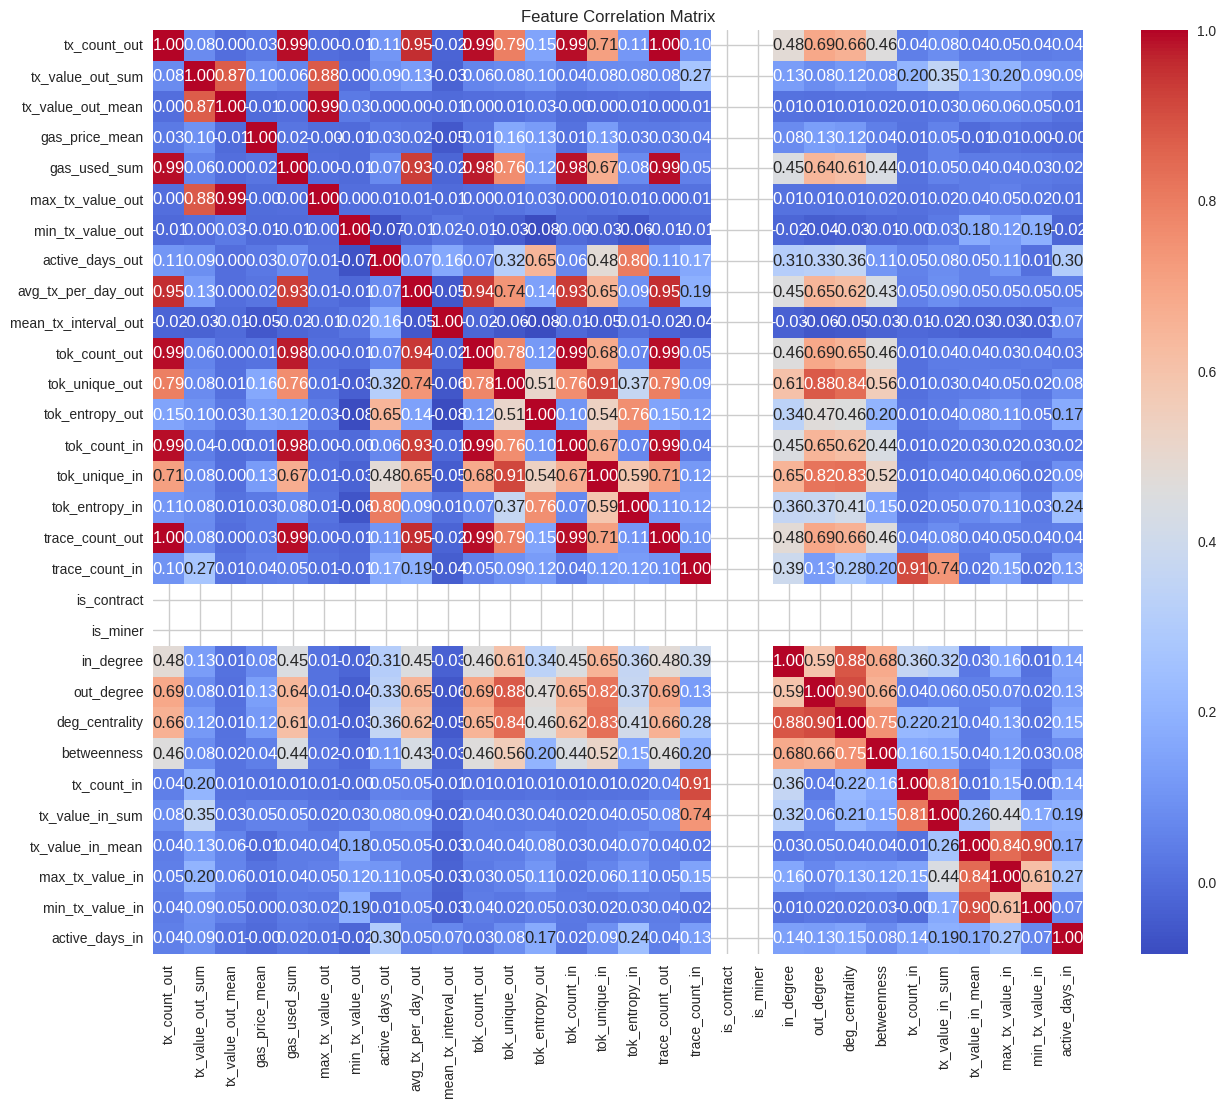

In [ ]:
num = df.select_dtypes(include='number')
corr = num.corr()

plt.figure(figsize=(15,12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()


Shape: (19575, 31)

Missing values per column:
 address               0
tx_count_out          0
tx_value_out_sum      0
tx_value_out_mean     0
gas_price_mean        0
gas_used_sum          0
max_tx_value_out      0
min_tx_value_out      0
active_days_out       0
avg_tx_per_day_out    0
dtype: int64

Descriptive stats:
                         count          mean           std           min  \
tx_count_out          19575.0  1.770605e+01  2.205328e+02  1.000000e+00   
tx_value_out_sum      19575.0  4.624030e+18  5.463891e+19  0.000000e+00   
tx_value_out_mean     19575.0  2.406368e+17  4.354188e+18  0.000000e+00   
gas_price_mean        19575.0  1.593284e+10  1.658202e+10  2.339014e+09   
gas_used_sum          19575.0  5.635896e+06  1.198679e+08  1.275250e+05   
max_tx_value_out      19575.0  1.411390e+18  4.724263e+19  0.000000e+00   
min_tx_value_out      19575.0  1.818485e+16  1.269518e+17  0.000000e+00   
active_days_out       19575.0  2.336143e+00  1.715605e+00  1.000000e+00   
avg

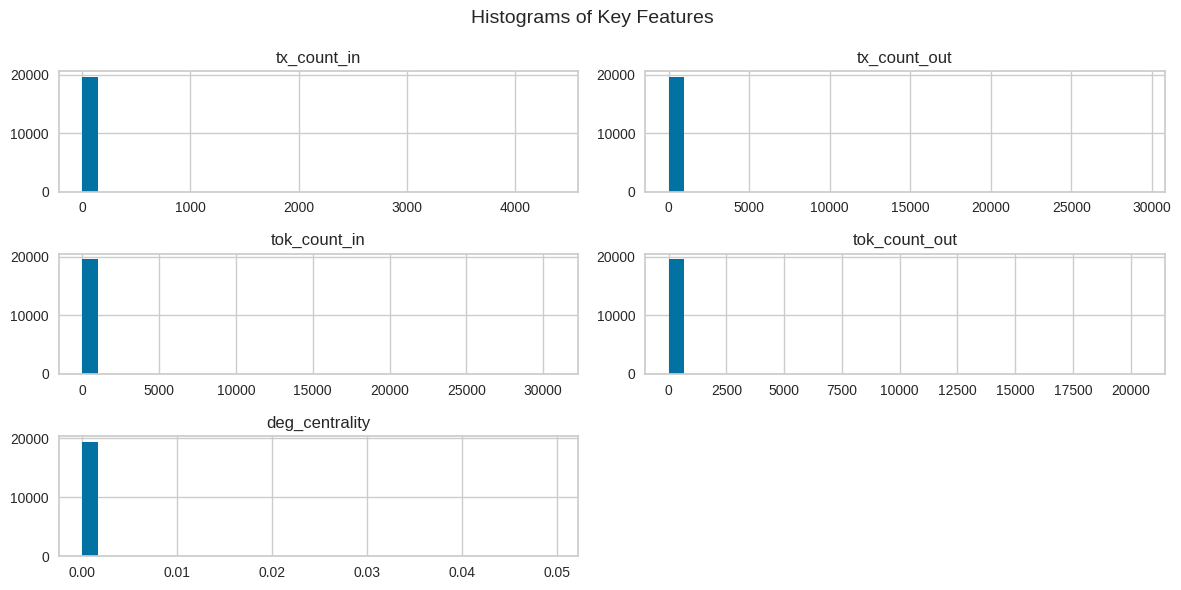

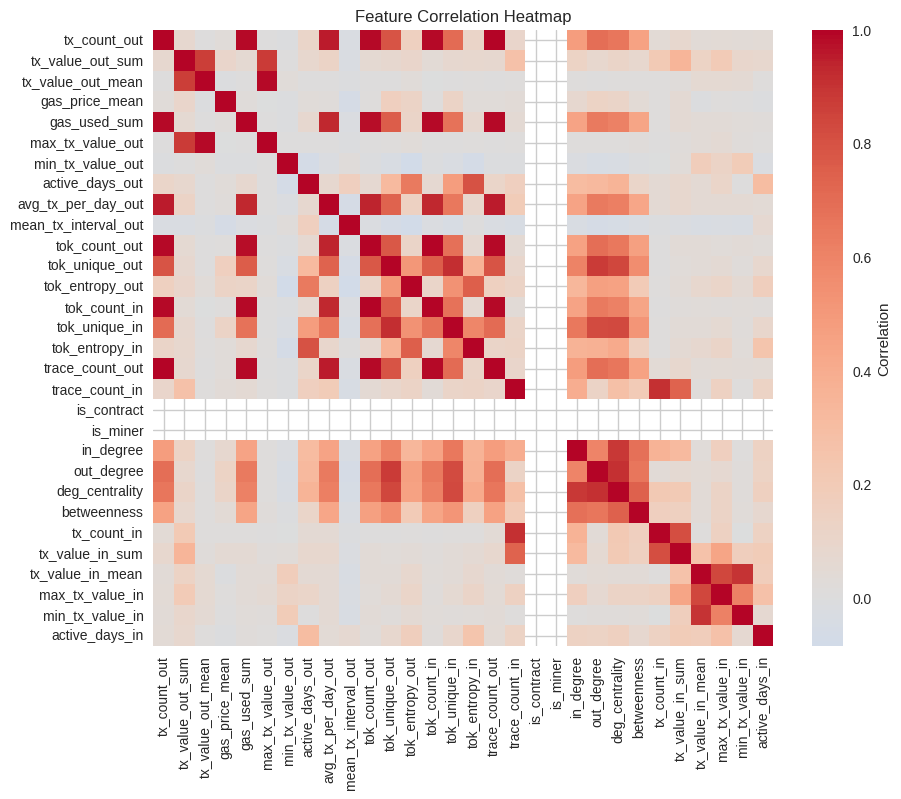

/tmp/ipython-input-1079058189.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='address', y='total_tx', data=top_wallets, palette="viridis")


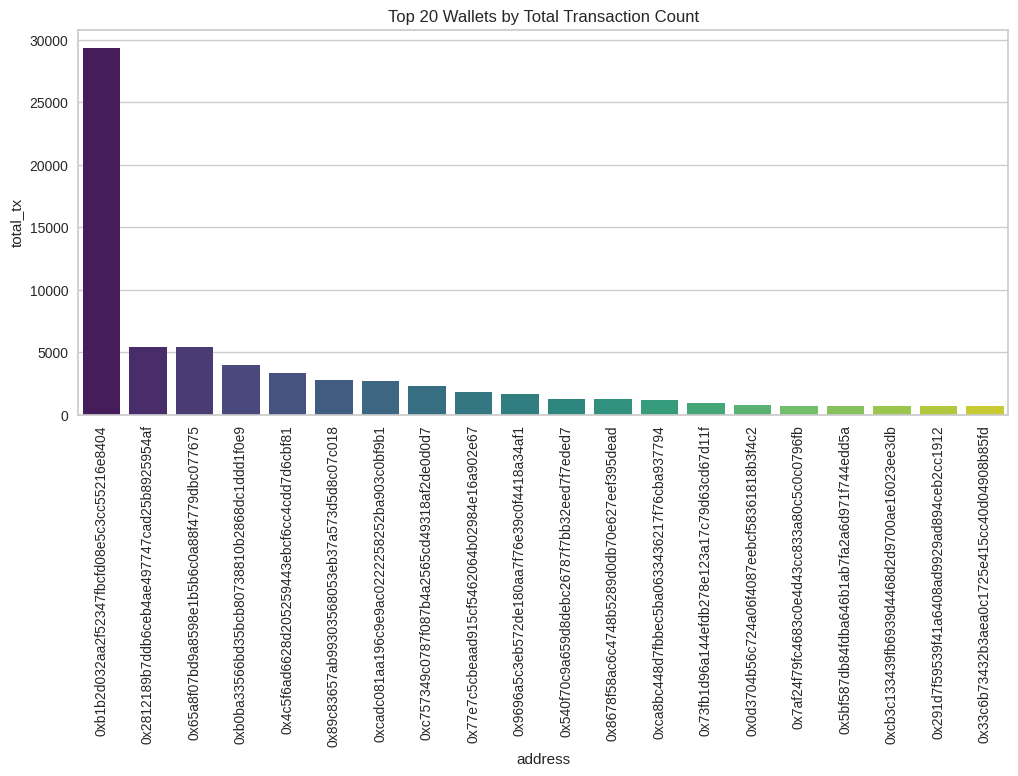

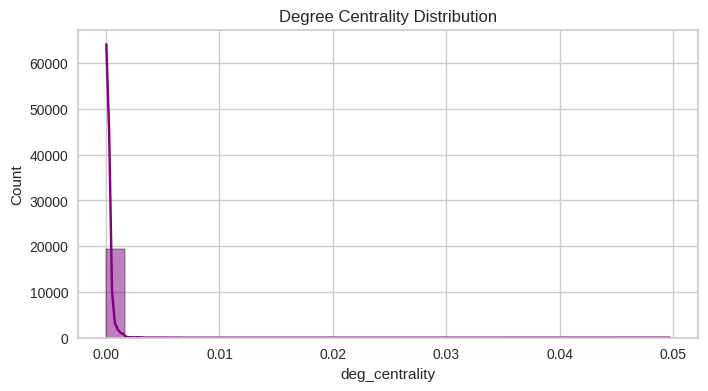

In [ ]:
print("Shape:", df.shape)
print("\nMissing values per column:\n", df.isna().sum().sort_values(ascending=False).head(10))
print("\nDescriptive stats:\n", df.describe().T.head(10))

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

key_feats = ['tx_count_in', 'tx_count_out', 'tok_count_in', 'tok_count_out', 'deg_centrality']
key_feats = [f for f in key_feats if f in df.columns]  # keep only existing
df[key_feats].hist(bins=30, figsize=(12, 6))
plt.suptitle("Histograms of Key Features", fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, cbar_kws={'label': 'Correlation'})
plt.title("Feature Correlation Heatmap")
plt.show()

if 'tx_count_in' in df.columns and 'tx_count_out' in df.columns:
    df['total_tx'] = df['tx_count_in'] + df['tx_count_out']
    top_wallets = df.sort_values('total_tx', ascending=False).head(20)
    plt.figure(figsize=(12, 5))
    sns.barplot(x='address', y='total_tx', data=top_wallets, palette="viridis")
    plt.xticks(rotation=90)
    plt.title("Top 20 Wallets by Total Transaction Count")
    plt.show()

if 'deg_centrality' in df.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df['deg_centrality'], bins=30, kde=True, color='purple')
    plt.title("Degree Centrality Distribution")
    plt.show()

## **1. Manual Statistical Clustering**

In [ ]:
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
numeric_data = df[numeric_columns].copy()


# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(numeric_data)

mmscaler = MinMaxScaler()
mmdata_scaled = mmscaler.fit_transform(numeric_data)

mask = np.any(np.isnan(data_scaled), axis=1)
data_scaled = data_scaled[~mask]

# Calculate the Euclidean distance matrix
distance_vector = pdist(data_scaled, metric='euclidean')
distance_matrix = squareform(distance_vector)

In [ ]:
def initialize_centroids(data, k):
    indices = np.random.choice(data.shape[0], k, replace=False)
    return data[indices]

def assign_clusters(data, centroids):
    distances = np.sqrt(((data - centroids[:, np.newaxis])**2).sum(axis=2))
    return np.argmin(distances, axis=0)

def update_centroids(data, labels, k):
    new_centroids = np.array([data[labels == i].mean(axis=0) for i in range(k)])
    return new_centroids

def kmeans(data, k, iterations=100):
    centroids = initialize_centroids(data, k)
    for _ in range(iterations):
        labels = assign_clusters(data, centroids)
        new_centroids = update_centroids(data, labels, k)
        if np.all(centroids == new_centroids):
            break
        centroids = new_centroids
    return labels, centroids

k = 3
labels, centroids = kmeans(data_scaled, k)

# Compute the Silhouette score
silhouette_kmeans = silhouette_score(data_scaled, labels)
print(f'Silhouette Score for K-Means: {silhouette_kmeans}')

Silhouette Score for K-Means: 0.45620581385522213


## **2. Classical Clustering Algorithms**

### **2.1 K-Means Clustering**

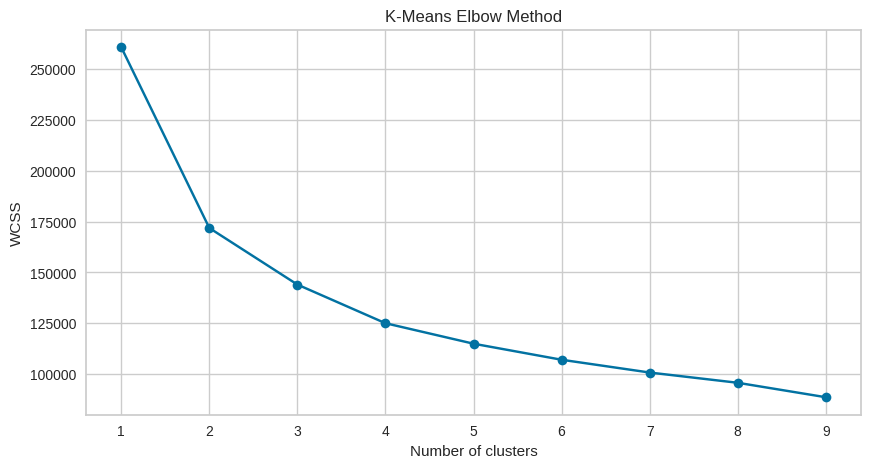

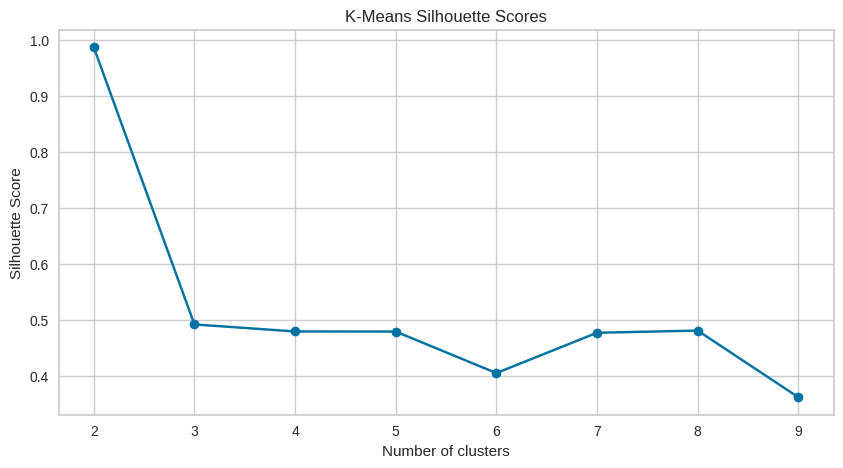

In [ ]:
wcss = []
max_clusters = 10

# WCSS calculation
for i in range(1, max_clusters):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(data_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, max_clusters), wcss, marker='o')
plt.title('K-Means Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# Silhouette scores
silhouette_scores = []
for i in range(2, max_clusters):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    labels = kmeans.fit_predict(data_scaled)
    silhouette_scores.append(silhouette_score(data_scaled, labels))

plt.figure(figsize=(10, 5))
plt.plot(range(2, max_clusters), silhouette_scores, marker='o')
plt.title('K-Means Silhouette Scores')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

K-Means Silhouette Score: 0.986767270257172
K-Means Calinski-Harabasz Score: 4816.023698014997
K-Means Davies-Bouldin Score: 0.009034432178910387
Cluster Counts: {np.int32(0): 9312, np.int32(1): 1}


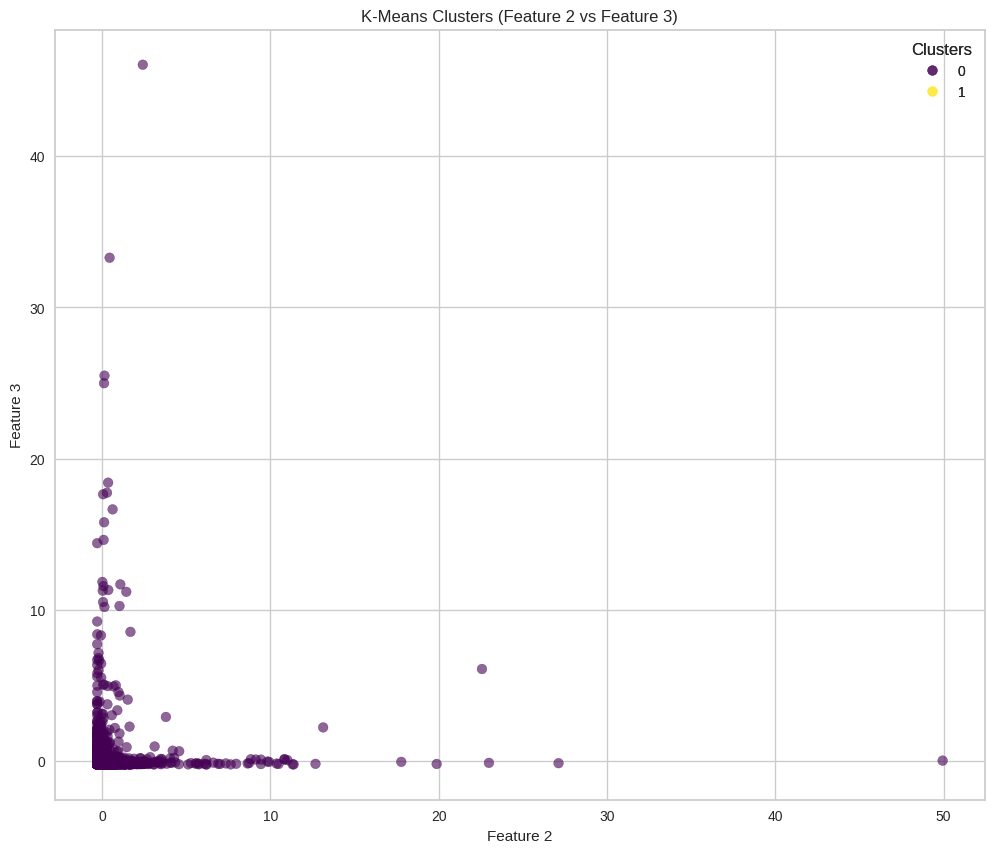

In [ ]:
optimal_k = 2
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_labels = kmeans.fit_predict(data_scaled)

# Evaluation metrics
silhouette_avg = silhouette_score(data_scaled, kmeans_labels)
calinski_harabasz = calinski_harabasz_score(data_scaled, kmeans_labels)
davies_bouldin = davies_bouldin_score(data_scaled, kmeans_labels)

# Cluster counts
counts = Counter(kmeans_labels)

print("K-Means Silhouette Score:", silhouette_avg)
print("K-Means Calinski-Harabasz Score:", calinski_harabasz)
print("K-Means Davies-Bouldin Score:", davies_bouldin)
print("Cluster Counts:", dict(counts))

# Scatter plot (using feature 2 vs feature 3)
clusters = kmeans_labels
data_column = data_scaled[:, 2]
plt.figure(figsize=(12, 10))
scatter = plt.scatter(data_column, data_scaled[:, 3], c=clusters, cmap='viridis', alpha=0.6)
legend1 = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend1)
plt.xlabel('Feature 2')
plt.ylabel('Feature 3')
plt.title('K-Means Clusters (Feature 2 vs Feature 3)')
plt.show()

### **2.2 Agglomerative Clustering**

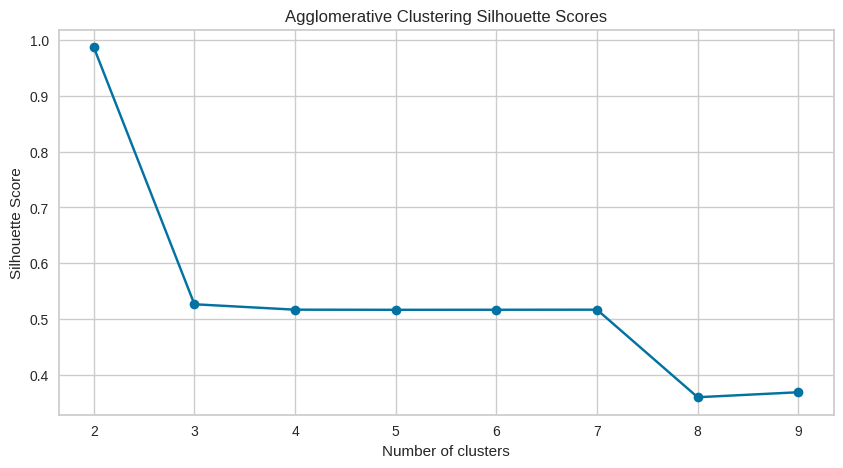

In [ ]:
silhouette_scores = []
davies_bouldin_scores = []
calinski_scores = []

for i in range(2, max_clusters):
    agg = AgglomerativeClustering(n_clusters=i)
    labels = agg.fit_predict(data_scaled)
    silhouette_scores.append(silhouette_score(data_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(data_scaled, labels))
    calinski_scores.append(calinski_harabasz_score(data_scaled, labels))

plt.figure(figsize=(10, 5))
plt.plot(range(2, max_clusters), silhouette_scores, marker='o')
plt.title('Agglomerative Clustering Silhouette Scores')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

Agglomerative Silhouette Score: 0.986767270257172
Agglomerative Calinski-Harabasz Score: 4816.023698014997
Agglomerative Davies-Bouldin Score: 0.009034432178910387
Cluster Counts: {np.int64(0): 9312, np.int64(1): 1}


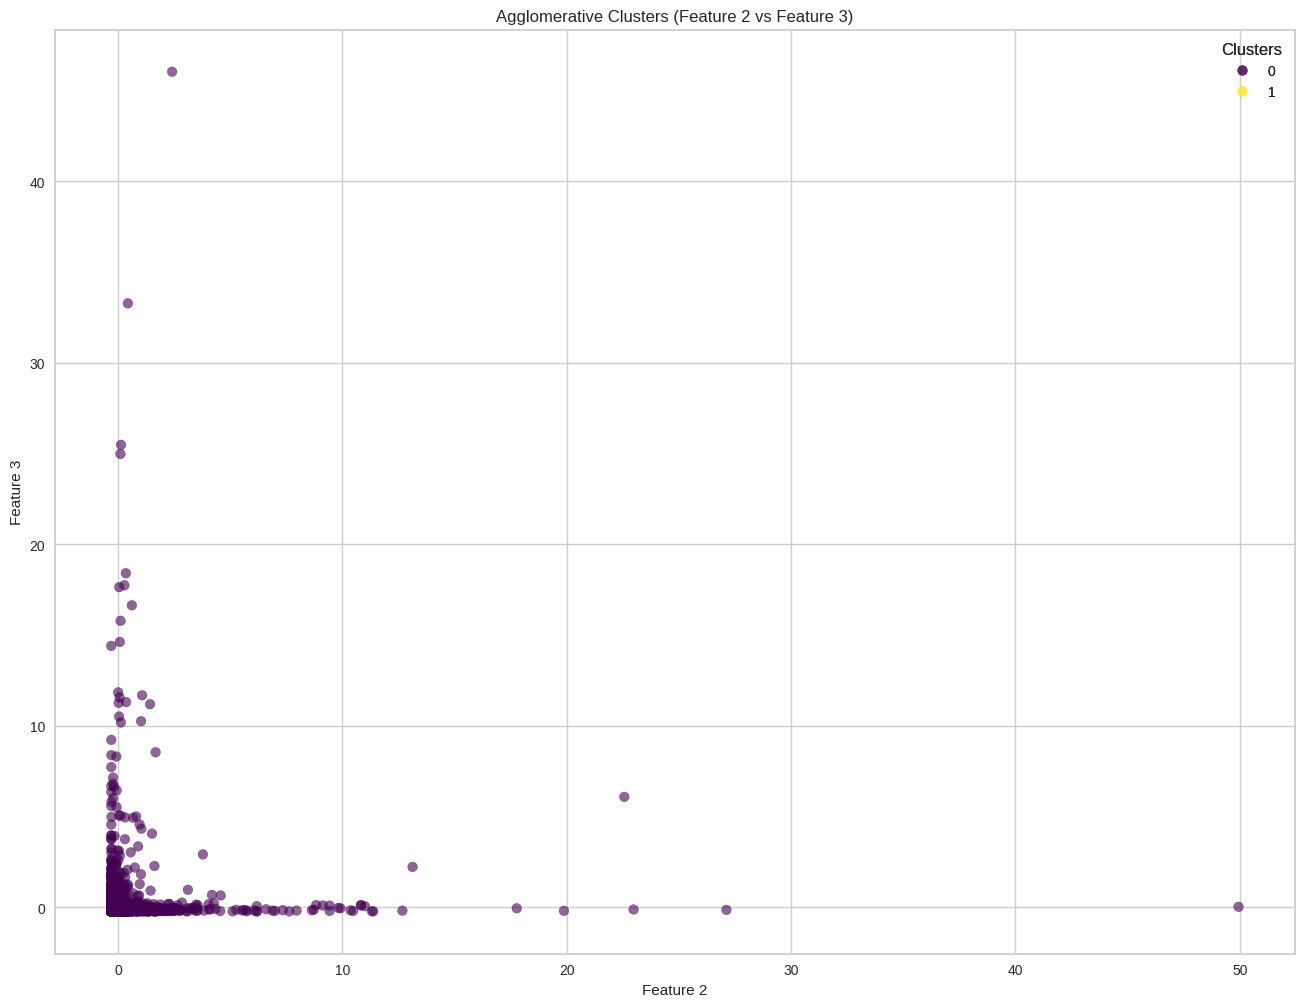

In [ ]:
optimal_k = 2
agg = AgglomerativeClustering(n_clusters=optimal_k)
agg_labels = agg.fit_predict(data_scaled)

silhouette_avg = silhouette_score(data_scaled, agg_labels)
calinski_harabasz = calinski_harabasz_score(data_scaled, agg_labels)
davies_bouldin = davies_bouldin_score(data_scaled, agg_labels)

counts = Counter(agg_labels)

print("Agglomerative Silhouette Score:", silhouette_avg)
print("Agglomerative Calinski-Harabasz Score:", calinski_harabasz)
print("Agglomerative Davies-Bouldin Score:", davies_bouldin)
print("Cluster Counts:", dict(counts))

clusters = agg_labels
data_column = data_scaled[:, 2]
plt.figure(figsize=(16, 12))
scatter = plt.scatter(data_column, data_scaled[:, 3], c=clusters, cmap='viridis', alpha=0.6)
legend1 = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend1)
plt.xlabel('Feature 2')
plt.ylabel('Feature 3')
plt.title('Agglomerative Clusters (Feature 2 vs Feature 3)')
plt.show()

### **2.3 GMM Clustering**

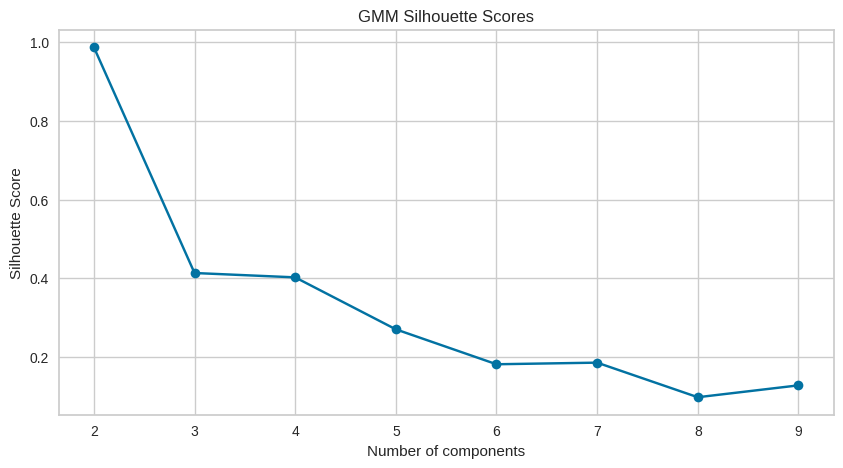

In [ ]:
bic_scores = []
aic_scores = []
silhouette_scores = []
davies_bouldin_scores = []
calinski_scores = []

for i in range(2, max_clusters):
    gmm = GaussianMixture(n_components=i, covariance_type='full', random_state=42)
    gmm.fit(data_scaled)
    labels = gmm.predict(data_scaled)
    silhouette_scores.append(silhouette_score(data_scaled, labels))
    bic_scores.append(gmm.bic(data_scaled))
    aic_scores.append(gmm.aic(data_scaled))
    davies_bouldin_scores.append(davies_bouldin_score(data_scaled, labels))
    calinski_scores.append(calinski_harabasz_score(data_scaled, labels))

plt.figure(figsize=(10, 5))
plt.plot(range(2, max_clusters), silhouette_scores, marker='o')
plt.title('GMM Silhouette Scores')
plt.xlabel('Number of components')
plt.ylabel('Silhouette Score')
plt.show()

GMM Silhouette Score: 0.986767270257172
GMM Calinski-Harabasz Score: 4816.023698014997
GMM Davies-Bouldin Score: 0.009034432178910387
Cluster Counts: {np.int64(0): 9312, np.int64(1): 1}


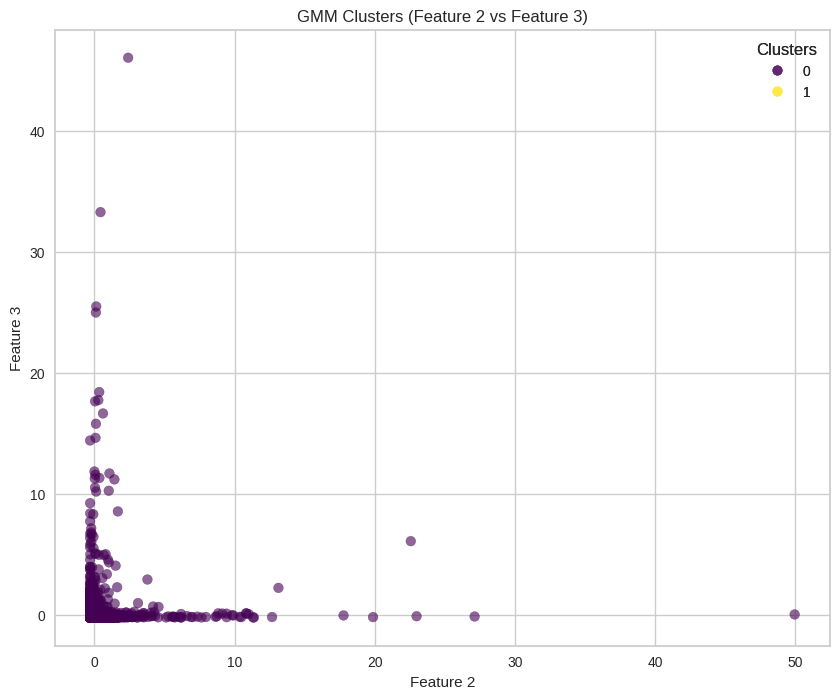

In [ ]:
optimal_k = 2
gmm = GaussianMixture(n_components=optimal_k, random_state=42)
gmm_labels = gmm.fit_predict(data_scaled)

silhouette_avg = silhouette_score(data_scaled, gmm_labels)
calinski_harabasz = calinski_harabasz_score(data_scaled, gmm_labels)
davies_bouldin = davies_bouldin_score(data_scaled, gmm_labels)

counts = Counter(gmm_labels)

print("GMM Silhouette Score:", silhouette_avg)
print("GMM Calinski-Harabasz Score:", calinski_harabasz)
print("GMM Davies-Bouldin Score:", davies_bouldin)
print("Cluster Counts:", dict(counts))

clusters = gmm_labels
data_column = data_scaled[:, 2]
plt.figure(figsize=(10, 8))
scatter = plt.scatter(data_column, data_scaled[:, 3], c=clusters, cmap='viridis', alpha=0.6)
legend1 = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend1)
plt.xlabel('Feature 2')
plt.ylabel('Feature 3')
plt.title('GMM Clusters (Feature 2 vs Feature 3)')
plt.show()

### **2.4 DBSCAN Clustering**

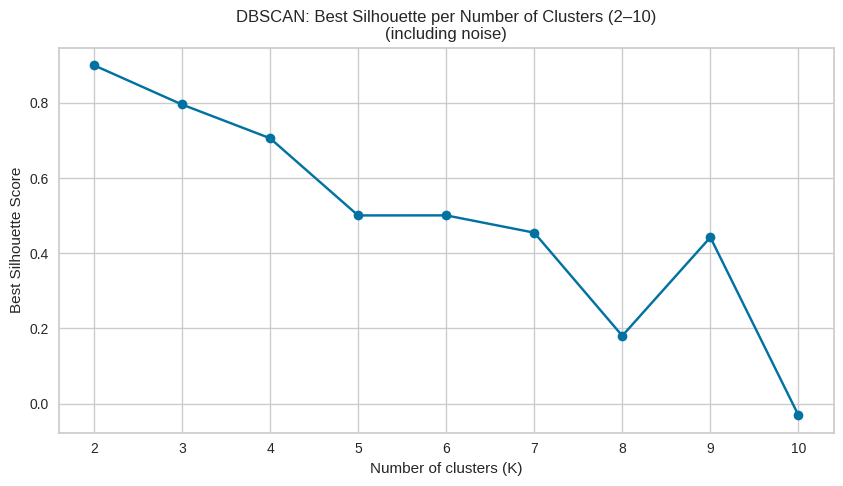

Search complete.
Best overall (including noise): {'sil': 0.8997287425836566, 'eps': 7.07703550590521, 'min_samples': 5, 'n_clusters': 2}
Best params by K (2–10) available in dict: best_params_by_k


In [ ]:
def dbscan_scores_including_noise(X, labels):
    if len(np.unique(labels)) < 2:
        return np.nan, np.nan, np.nan
    sil = silhouette_score(X, labels)
    ch  = calinski_harabasz_score(X, labels)
    db  = davies_bouldin_score(X, labels)
    return sil, ch, db

min_samples_list = [3, 5, 10, 20]
k_for_knn = max(min_samples_list)

nbrs = NearestNeighbors(n_neighbors=k_for_knn).fit(data_scaled)
distances, _ = nbrs.kneighbors(data_scaled)
k_dists = np.sort(distances[:, -1])

eps_low, eps_high = np.percentile(k_dists, 50), np.percentile(k_dists, 99)
eps_candidates = np.linspace(eps_low, eps_high, 25)

best_overall = {"sil": -1, "eps": None, "min_samples": None, "n_clusters": None}
best_by_k = {k: -1 for k in range(2, 11)}
best_params_by_k = {}

for ms in min_samples_list:
    for eps in eps_candidates:
        db = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1)
        labels = db.fit_predict(data_scaled)

        n_clusters = len(np.unique(labels))
        if n_clusters < 2 or n_clusters > 10:
            continue

        try:
            sil, ch, dbi = dbscan_scores_including_noise(data_scaled, labels)
        except Exception:
            continue
        if np.isnan(sil):
            continue

        if sil > best_by_k[n_clusters]:
            best_by_k[n_clusters] = sil
            best_params_by_k[n_clusters] = {
                "eps": float(eps), "min_samples": int(ms), "sil": float(sil)
            }

        if sil > best_overall["sil"]:
            best_overall = {
                "sil": float(sil), "eps": float(eps),
                "min_samples": int(ms), "n_clusters": int(n_clusters)
            }

xs = list(range(2, 11))
ys = [best_by_k[k] if best_by_k[k] != -1 else np.nan for k in xs]

plt.figure(figsize=(10, 5))
plt.plot(xs, ys, marker='o')
plt.title('DBSCAN: Best Silhouette per Number of Clusters (2–10)\n(including noise)')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Best Silhouette Score')
plt.show()

print("Search complete.")
print("Best overall (including noise):", best_overall)
print("Best params by K (2–10) available in dict: best_params_by_k")



=== DBSCAN Final Configuration ===
Chosen K (clusters): 3 (targeted K=3)
Best eps for K=3: 7.07703550590521
Best min_samples for K=3: 3
Silhouette: 0.7954
Calinski-Harabasz: 428.28
Davies-Bouldin: 2.1623

Points per label:
       count
label       
-1        46
 0      9261
 1         6

Noise points (label = -1): 46


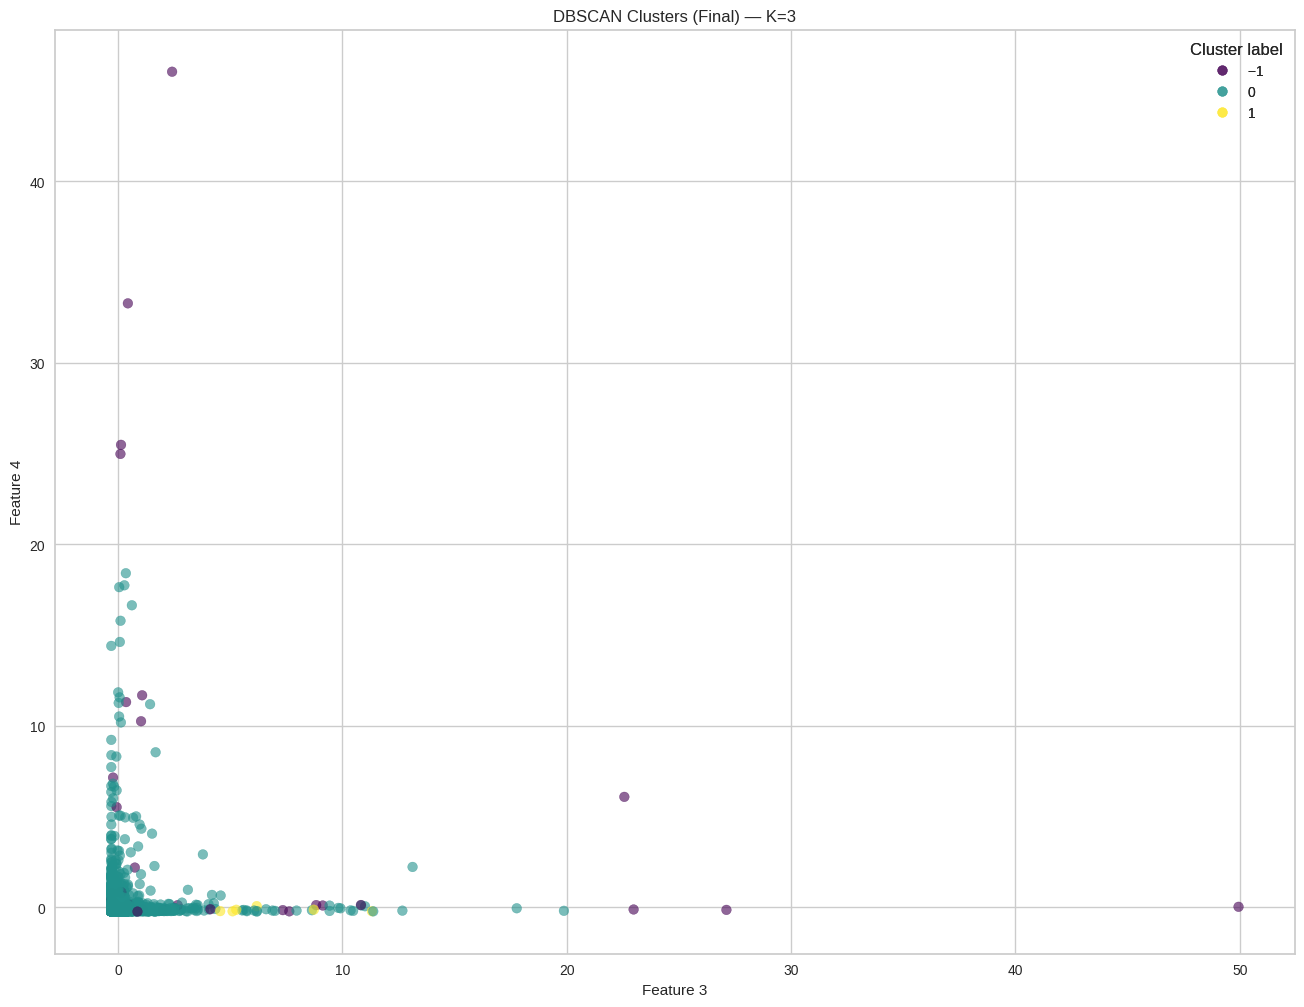

In [ ]:
k_selected = 3
if k_selected not in best_params_by_k:
    if best_overall["n_clusters"] is not None and best_overall["n_clusters"] in best_params_by_k:
        k_selected = best_overall["n_clusters"]
        print(f"Requested K not found. Falling back to best overall K={k_selected}.")
    else:
        available_ks = sorted(best_params_by_k.keys())
        if not available_ks:
            raise ValueError("No valid DBSCAN configurations found for K in [2..10].")
        k_selected = max(available_ks, key=lambda k: best_params_by_k[k]["sil"])
        print(f"Requested K not found. Falling back to best available K={k_selected}.")

params = best_params_by_k[k_selected]
best_dbscan_eps = params["eps"]
best_dbscan_min_samples = params["min_samples"]

db_final = DBSCAN(eps=best_dbscan_eps, min_samples=best_dbscan_min_samples, n_jobs=-1)
dbscan_labels = db_final.fit_predict(data_scaled)

# Use the new scoring function that evaluates all labels as predicted
dbscan_silhouette, dbscan_calinski, dbscan_davies = dbscan_scores_including_noise(data_scaled, dbscan_labels)

labels_series = pd.Series(dbscan_labels, name="label")
noise_count = int((labels_series == -1).sum())
cluster_counts = labels_series.value_counts().sort_index()  # includes -1
optimal_dbscan_clusters = labels_series.nunique()  # counts all distinct labels

print("\n=== DBSCAN Final Configuration ===")
print(f"Chosen K (clusters): {optimal_dbscan_clusters} (targeted K={k_selected})")
print(f"Best eps for K={k_selected}: {best_dbscan_eps}")
print(f"Best min_samples for K={k_selected}: {best_dbscan_min_samples}")
print(f"Silhouette: {dbscan_silhouette:.4f}" if pd.notna(dbscan_silhouette) else "Silhouette: NaN")
print(f"Calinski-Harabasz: {dbscan_calinski:.2f}" if pd.notna(dbscan_calinski) else "Calinski-Harabasz: NaN")
print(f"Davies-Bouldin: {dbscan_davies:.4f}" if pd.notna(dbscan_davies) else "Davies-Bouldin: NaN")

print("\nPoints per label:")
print(cluster_counts.rename("count").to_frame())

print(f"\nNoise points (label = -1): {noise_count}")

ix, iy = (2, 3) if data_scaled.shape[1] > 3 else (0, 1)
plt.figure(figsize=(16, 12))
scatter = plt.scatter(data_scaled[:, ix], data_scaled[:, iy], c=dbscan_labels, cmap='viridis', alpha=0.6)
legend1 = plt.legend(*scatter.legend_elements(), title="Cluster label")
plt.gca().add_artist(legend1)
plt.xlabel(f'Feature {ix+1}')
plt.ylabel(f'Feature {iy+1}')
plt.title(f'DBSCAN Clusters (Final) — K={optimal_dbscan_clusters}')
plt.show()


Cluster counts:
        count
label       
-1        46
 0      9261
 1         6

Cluster proportions:
        proportion
label            
-1       0.004939
 0       0.994416
 1       0.000644

Per-cluster means (scaled space):
              f1        f2        f3        f4        f5        f6        f7  \
label                                                                         
-1     3.274151  3.942519  3.979376  4.041202  2.972027  5.169475  2.794565   
 0    -0.016254 -0.020277 -0.024212 -0.019986 -0.014756 -0.028364 -0.014623   
 1    -0.013193  1.071506  6.863007 -0.134389 -0.009131  4.147654  1.145687   

             f8        f9       f10  ...       f21       f22       f23  \
label                                ...                                 
-1     1.263142  3.417959 -0.249553  ...  5.161465  5.018140  5.456790   
 0    -0.006418 -0.016975  0.001273  ... -0.025656 -0.024921 -0.027111   
 1     0.222481 -0.003537 -0.051591  ...  0.028783 -0.006770  0.009813   

  

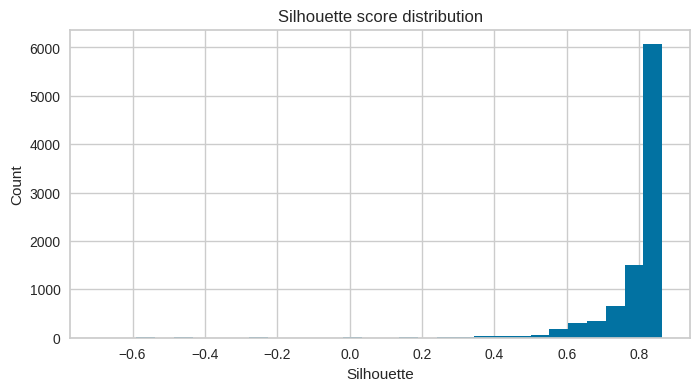

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:579: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)



Feature effect sizes (sorted by eta^2):
    feature  eta2_anova        p_anova  h_kruskal     p_kruskal
27     f28    0.201102   0.000000e+00  60.126990  8.781933e-14
23     f24    0.195445   0.000000e+00  73.959409  8.708001e-17
17     f18    0.161661   0.000000e+00  58.078933  2.445231e-13
22     f23    0.147807  4.940656e-324  70.713423  4.413421e-16
5       f6    0.143879  8.915843e-315  81.476752  2.030244e-18
26     f27    0.137872  1.219303e-300  51.459016  6.696019e-12
20     f21    0.132242  1.756267e-287  52.960291  3.160959e-12
24     f25    0.126235  1.558615e-273  85.996231  2.119121e-19
21     f22    0.124999  1.124305e-270  64.369808  1.052625e-14
2       f3    0.109145  2.251342e-234  43.169888  4.224525e-10
11     f12    0.107446  1.599333e-230  72.398920  1.900091e-16
25     f26    0.103298  3.770196e-221  67.487431  2.214575e-15
14     f15    0.084037  3.472710e-178  37.007857  9.201231e-09
3       f4    0.081075  1.173775e-171  33.035086  6.706907e-08
1       f2   

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
try:
    feature_names
except NameError:
    feature_names = [f"f{i+1}" for i in range(data_scaled.shape[1])]

X = data_scaled
y = dbscan_labels
labels_unique = np.unique(y)
n_clusters_total = len(labels_unique)

def cluster_summary(X, y, feature_names):
    df = pd.DataFrame(X, columns=feature_names).assign(label=y)
    counts = df['label'].value_counts().sort_index()
    props = (counts / len(df)).rename("proportion")
    by_cluster_mean = df.groupby('label')[feature_names].mean()
    by_cluster_std  = df.groupby('label')[feature_names].std(ddof=0)
    return {
        "counts": counts.to_frame("count"),
        "proportions": props.to_frame(),
        "means": by_cluster_mean,
        "stds": by_cluster_std
    }

summary = cluster_summary(X, y, feature_names)
print("Cluster counts:\n", summary["counts"])
print("\nCluster proportions:\n", summary["proportions"])
print("\nPer-cluster means (scaled space):\n", summary["means"])
print("\nPer-cluster stds (scaled space):\n", summary["stds"])


def silhouette_diagnostics(X, y):
    if len(np.unique(y)) < 2:
        return {"silhouette_global": np.nan, "silhouette_by_label": None, "silhouette_samples": None}
    s = silhouette_samples(X, y)
    sg = silhouette_score(X, y)
    sil_by_label = pd.Series(index=np.unique(y), dtype=float)
    for lbl in np.unique(y):
        sil_by_label.loc[lbl] = np.nanmean(s[y == lbl]) if np.any(y == lbl) else np.nan
    return {"silhouette_global": sg, "silhouette_by_label": sil_by_label, "silhouette_samples": s}

sil = silhouette_diagnostics(X, y)
print("\nSilhouette (global):", np.round(sil["silhouette_global"], 4))
print("\nSilhouette by label:\n", sil["silhouette_by_label"])

plt.figure(figsize=(8,4))
plt.hist(sil["silhouette_samples"][~np.isnan(sil["silhouette_samples"])], bins=30)
plt.title("Silhouette score distribution")
plt.xlabel("Silhouette")
plt.ylabel("Count")
plt.show()


def feature_effect_sizes(X, y, feature_names):
    out = []
    groups = [X[y == lbl] for lbl in np.unique(y)]
    for j, fname in enumerate(feature_names):
        try:
            f_stat, p_anova = stats.f_oneway(*[g[:, j] for g in groups if len(g) > 1])
        except Exception:
            f_stat, p_anova = np.nan, np.nan
        xj = X[:, j]
        overall_mean = np.mean(xj)
        ssb = 0.0
        for g in groups:
            if len(g) == 0:
                continue
            ssb += len(g) * (np.mean(g[:, j]) - overall_mean) ** 2
        sst = np.sum((xj - overall_mean) ** 2)
        eta2 = ssb / sst if sst > 0 else np.nan

        try:
            h_stat, p_kw = stats.kruskal(*[g[:, j] for g in groups if len(g) > 1])
        except Exception:
            h_stat, p_kw = np.nan, np.nan

        out.append((fname, eta2, p_anova, h_stat, p_kw))
    df = pd.DataFrame(out, columns=["feature", "eta2_anova", "p_anova", "h_kruskal", "p_kruskal"])
    df = df.sort_values("eta2_anova", ascending=False)
    return df

effects = feature_effect_sizes(X, y, feature_names)
print("\nFeature effect sizes (sorted by eta^2):\n", effects.head(15))


def discriminative_feature_rankings(X, y, feature_names, random_state=42):
    mi = mutual_info_classif(X, y, random_state=random_state, discrete_features=False)
    mi_df = pd.DataFrame({"feature": feature_names, "mutual_info": mi}).sort_values("mutual_info", ascending=False)

    rf = RandomForestClassifier(n_estimators=400, random_state=random_state, n_jobs=-1, class_weight="balanced_subsample")
    rf.fit(X, y)
    rf_imp = pd.DataFrame({"feature": feature_names, "rf_importance": rf.feature_importances_}) \
                .sort_values("rf_importance", ascending=False)

    perm = permutation_importance(rf, X, y, scoring=None, n_repeats=10, random_state=random_state, n_jobs=-1)
    perm_df = pd.DataFrame({"feature": feature_names, "perm_importance": perm.importances_mean}) \
                .sort_values("perm_importance", ascending=False)

    lr = LogisticRegression(penalty="l1", solver="saga", multi_class="ovr", max_iter=5000, C=1.0, n_jobs=-1)
    lr.fit(X, y)
    coef_abs = np.abs(lr.coef_)
    coef_mean = coef_abs.mean(axis=0)
    lr_df = pd.DataFrame({"feature": feature_names, "logreg_l1_coef": coef_mean}) \
                .sort_values("logreg_l1_coef", ascending=False)

    return mi_df, rf_imp, perm_df, lr_df, rf

mi_df, rf_imp, perm_df, lr_df, rf_model = discriminative_feature_rankings(X, y, feature_names)

print("\nTop features by Mutual Information:\n", mi_df.head(15))
print("\nTop features by RandomForest importance:\n", rf_imp.head(15))
print("\nTop features by Permutation importance (RF):\n", perm_df.head(15))
print("\nTop features by L1-Logistic coefficients:\n", lr_df.head(15))

topn = 15
plt.figure(figsize=(10,5))
plt.bar(perm_df["feature"].head(topn), perm_df["perm_importance"].head(topn))
plt.title(f"Top {topn} features by permutation importance (RF)")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Mean decrease in score")
plt.tight_layout()
plt.show()


def cluster_profiles(X, y, feature_names):
    df = pd.DataFrame(X, columns=feature_names).assign(label=y)
    overall_mean = df[feature_names].mean()
    overall_std  = df[feature_names].std(ddof=0).replace(0, np.nan)
    rows = []
    for lbl in sorted(df['label'].unique()):
        sub = df[df['label'] == lbl][feature_names]
        m = sub.mean()
        s = (m - overall_mean) / overall_std
        row = pd.concat([m.add_suffix("_mean"), s.add_suffix("_smd")])
        row["n"] = len(sub)
        row["label"] = lbl
        rows.append(row)
    prof = pd.DataFrame(rows).set_index("label").sort_index()
    return prof

profiles = cluster_profiles(X, y, feature_names)
print("\nCluster profiles (means and standardized mean diffs vs overall):\n")
display_cols = ["n"] + \
               [c for c in profiles.columns if c.endswith("_mean")] + \
               [c for c in profiles.columns if c.endswith("_smd")]
print(profiles[display_cols].round(3))


def plot_pca_scatter(X, y, feature_names, n_components=2):
    pca = PCA(n_components=n_components, random_state=42)
    Z = pca.fit_transform(X)
    print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 4))
    plt.figure(figsize=(8,6))
    plt.scatter(Z[:,0], Z[:,1], c=y, alpha=0.6)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA scatter")
    plt.show()
    return Z, pca

Z2, pca2 = plot_pca_scatter(X, y, feature_names, n_components=2)

def pairwise_tests(X, y, feature_names, nonparam=False):
    labels = np.unique(y)
    pairs = [(a,b) for i,a in enumerate(labels) for b in labels[i+1:]]
    results = []
    for fname_idx, fname in enumerate(feature_names):
        for (a,b) in pairs:
            xa = X[y == a, fname_idx]
            xb = X[y == b, fname_idx]
            if nonparam:
                stat, p = stats.mannwhitneyu(xa, xb, alternative="two-sided")
                test = "MWU"
            else:
                stat, p = stats.ttest_ind(xa, xb, equal_var=False)
                test = "t-test"
            results.append((fname, a, b, test, stat, p))
    df = pd.DataFrame(results, columns=["feature","label_a","label_b","test","stat","p"])
    df["p_adj"] = np.minimum(df["p"] * len(df), 1.0)
    return df.sort_values("p_adj")

### **2.5 Algorithm Results Comparison**

In [ ]:
def safe_metrics(X, labels):
    try:
        uniq = [l for l in np.unique(labels) if l != -1]
        if len(uniq) < 2:
            return (np.nan, np.nan, np.nan)
        sil = silhouette_score(X, labels)
        dbi = davies_bouldin_score(X, labels)
        ch  = calinski_harabasz_score(X, labels)
        return (sil, dbi, ch)
    except Exception:
        return (np.nan, np.nan, np.nan)

rows = []

# K-Means
if 'kmeans_labels' in globals():
    kmeans_k = len(np.unique(kmeans_labels))
    sil, dbi, ch = safe_metrics(data_scaled, kmeans_labels)
    rows.append({"Algorithm":"K-Means","Best_k":kmeans_k,"Silhouette":sil,"DaviesBouldin":dbi,"Calinski":ch})

# GMM
if 'gmm_labels' in globals():
    gmm_k = len(np.unique(gmm_labels))
    sil, dbi, ch = safe_metrics(data_scaled, gmm_labels)
    rows.append({"Algorithm":"GMM","Best_k":gmm_k,"Silhouette":sil,"DaviesBouldin":dbi,"Calinski":ch})

# Agglomerative
if 'agg_labels' in globals():
    agg_k = len(np.unique(agg_labels))
    sil, dbi, ch = safe_metrics(data_scaled, agg_labels)
    rows.append({"Algorithm":"Agglomerative","Best_k":agg_k,"Silhouette":sil,"DaviesBouldin":dbi,"Calinski":ch})

# DBSCAN
if 'dbscan_labels' in globals():
    # exclude noise (-1) when counting clusters
    dbscan_k = len([l for l in np.unique(dbscan_labels) if l != -1])
    sil, dbi, ch = safe_metrics(data_scaled, dbscan_labels)
    rows.append({"Algorithm":"DBSCAN","Best_k":dbscan_k,"Silhouette":sil,"DaviesBouldin":dbi,"Calinski":ch})

comparison_df = pd.DataFrame(rows, columns=["Algorithm","Best_k","Silhouette","DaviesBouldin","Calinski"])
print("\n=== Best Results for Each Algorithm ===")
print(comparison_df.to_string(index=False))



=== Best Results for Each Algorithm ===
    Algorithm  Best_k  Silhouette  DaviesBouldin    Calinski
      K-Means       2    0.986767       0.009034 4816.023698
          GMM       2    0.986767       0.009034 4816.023698
Agglomerative       2    0.986767       0.009034 4816.023698
       DBSCAN       2    0.795379       2.162330  428.277863


## **Principal Component Analysis**

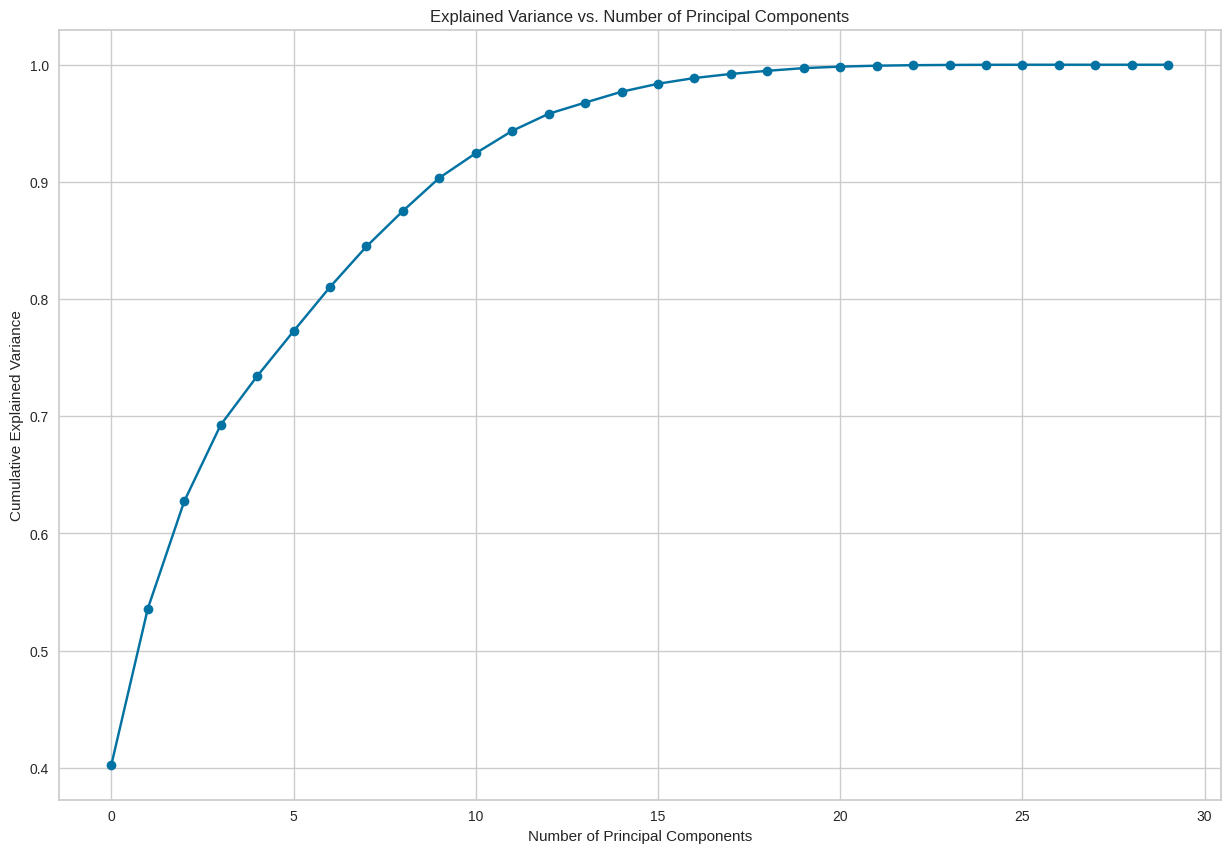

In [ ]:
pca = PCA()
pca.fit(data_scaled)

cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(15, 10))
plt.plot(cumulative_explained_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Principal Components')
plt.grid(True)
plt.show()

In [ ]:
n_components = 11
pca = PCA(n_components=n_components)
data_pca = pca.fit_transform(data_scaled)

print(f'Original shape: {data_scaled.shape}')
print(f'Transformed shape: {data_pca.shape}')

Original shape: (9313, 30)
Transformed shape: (9313, 11)


### **3.1 K-Means after PCA**

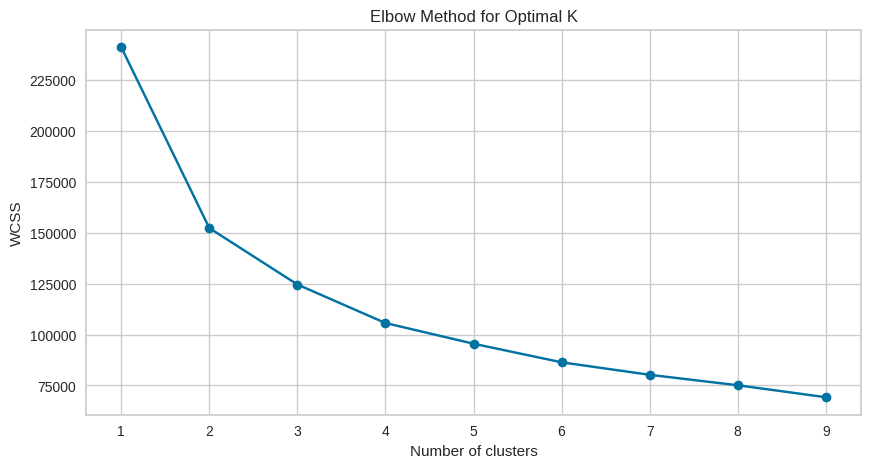

In [ ]:
wcss = []
max_clusters = 10

for i in range(1, max_clusters):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(data_pca)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Method graph
plt.figure(figsize=(10, 5))
plt.plot(range(1, max_clusters), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

K-Means Silhouette Score:  0.5088779376536684
K-Means Calinski-Harabasz Score:  4353.393775967827
K-Means Davies-Bouldin Score:  0.827431131977379
Cluster 0: 1948 points
Cluster 1: 1 points
Cluster 2: 7364 points


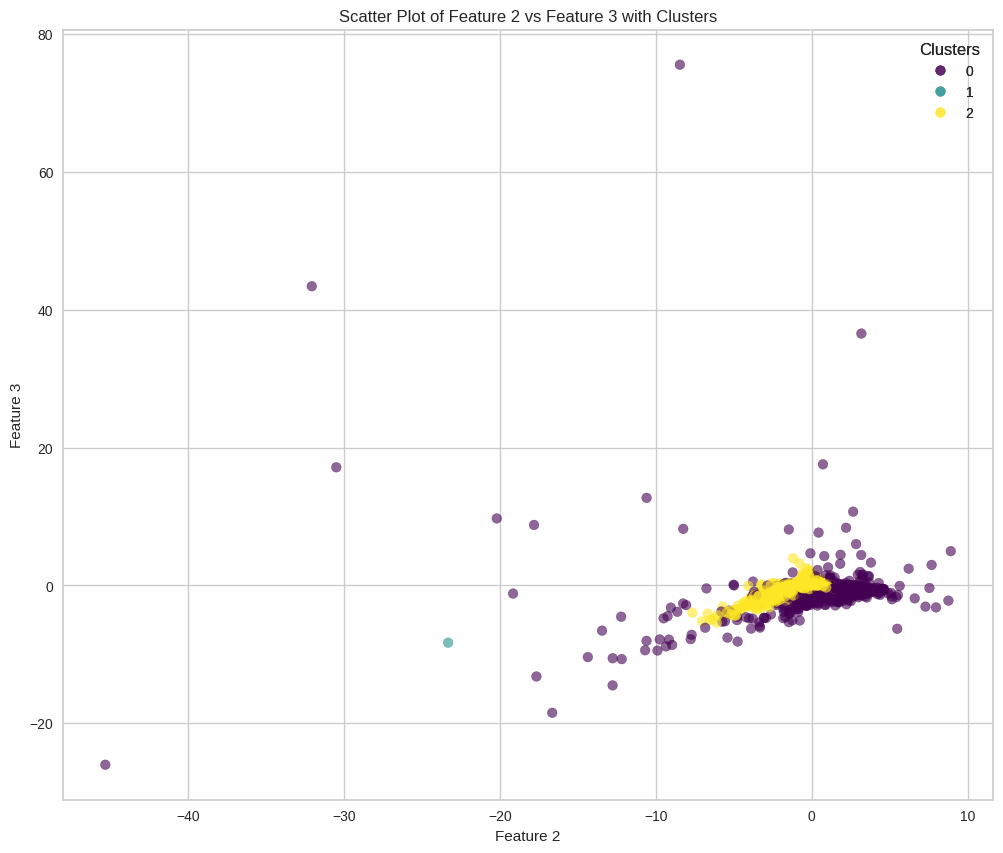

In [ ]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_labels = kmeans.fit_predict(data_pca)

silhouette_avg = silhouette_score(data_pca, kmeans_labels)
calinski_harabasz = calinski_harabasz_score(data_pca, kmeans_labels)
davies_bouldin = davies_bouldin_score(data_pca, kmeans_labels)

print("K-Means Silhouette Score: ", silhouette_avg)
print("K-Means Calinski-Harabasz Score: ", calinski_harabasz)
print("K-Means Davies-Bouldin Score: ", davies_bouldin)

unique, counts = np.unique(kmeans_labels, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"Cluster {cluster_id}: {count} points")

clusters = kmeans_labels
plt.figure(figsize=(12, 10))
scatter = plt.scatter(data_pca[:, 2], data_pca[:, 3], c=clusters, cmap='viridis', alpha=0.6)
legend1 = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend1)
plt.xlabel('Feature 2')
plt.ylabel('Feature 3')
plt.title('Scatter Plot of Feature 2 vs Feature 3 with Clusters')
plt.show()

### **3.2 Agglomerative Cluster after PCA**

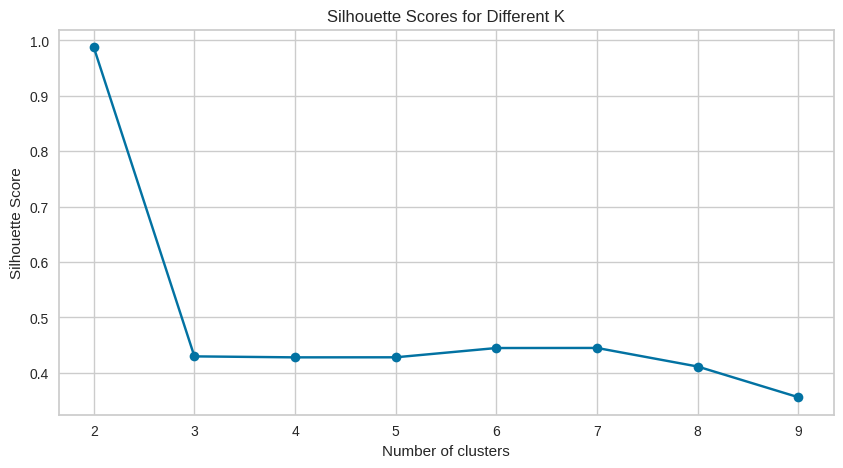

In [ ]:
silhouette_scores = []
max_clusters = 10

for i in range(2, max_clusters):
    agglomerative_clustering = AgglomerativeClustering(n_clusters=i)
    labels = agglomerative_clustering.fit_predict(data_pca)
    silhouette_scores.append(silhouette_score(data_pca, labels))

plt.figure(figsize=(10, 5))
plt.plot(range(2, max_clusters), silhouette_scores, marker='o')
plt.title('Silhouette Scores for Different K')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

Agglomerative Silhouette Score:  0.9877080938842163
Agglomerative Calinski-Harabasz Score:  5430.742811159437
Agglomerative Davies-Bouldin Score:  0.00843554932333845
Cluster 0: 9312 points
Cluster 1: 1 points


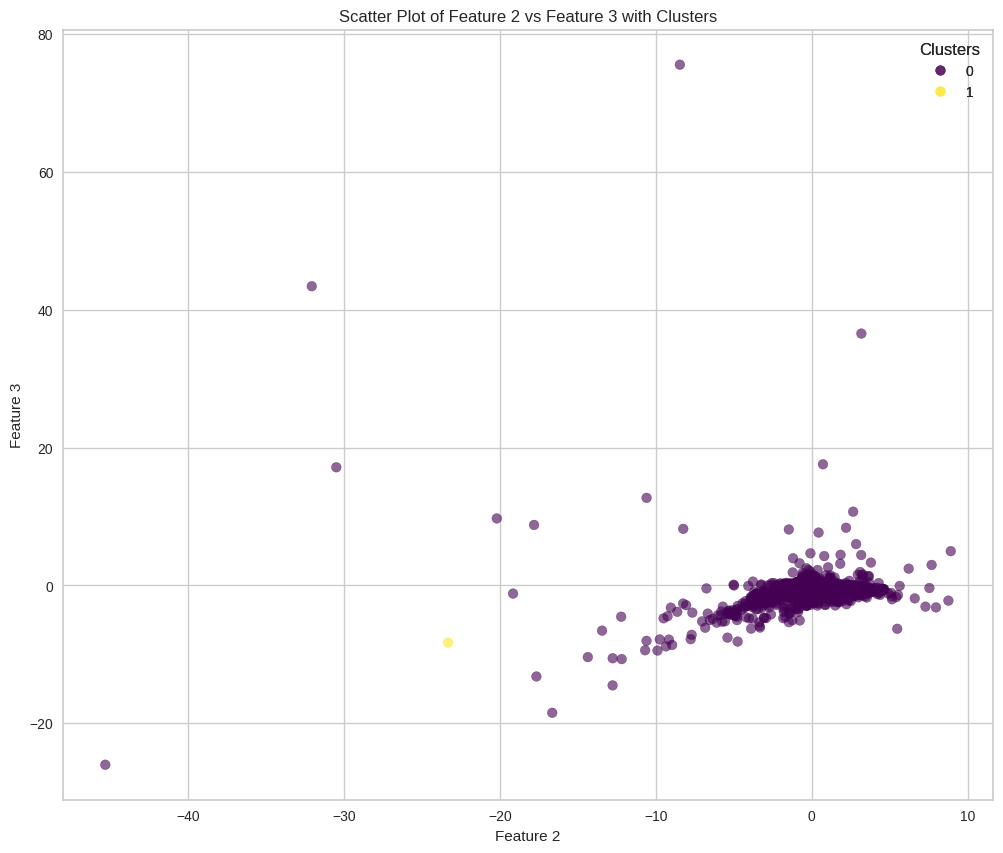

In [ ]:
optimal_k = 2
agglomerative_clustering = AgglomerativeClustering(n_clusters=optimal_k)
labels_ag = agglomerative_clustering.fit_predict(data_pca)

silhouette_avg = silhouette_score(data_pca, labels_ag)
calinski_harabasz = calinski_harabasz_score(data_pca, labels_ag)
davies_bouldin = davies_bouldin_score(data_pca, labels_ag)

print("Agglomerative Silhouette Score: ", silhouette_avg)
print("Agglomerative Calinski-Harabasz Score: ", calinski_harabasz)
print("Agglomerative Davies-Bouldin Score: ", davies_bouldin)

unique, counts = np.unique(labels_ag, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"Cluster {cluster_id}: {count} points")

clusters = labels_ag
plt.figure(figsize=(12, 10))
scatter = plt.scatter(data_pca[:, 2], data_pca[:, 3], c=clusters, cmap='viridis', alpha=0.6)
legend1 = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend1)
plt.xlabel('Feature 2')
plt.ylabel('Feature 3')
plt.title('Scatter Plot of Feature 2 vs Feature 3 with Clusters')
plt.show()

###**3.3 GMM Clustering After PCA**

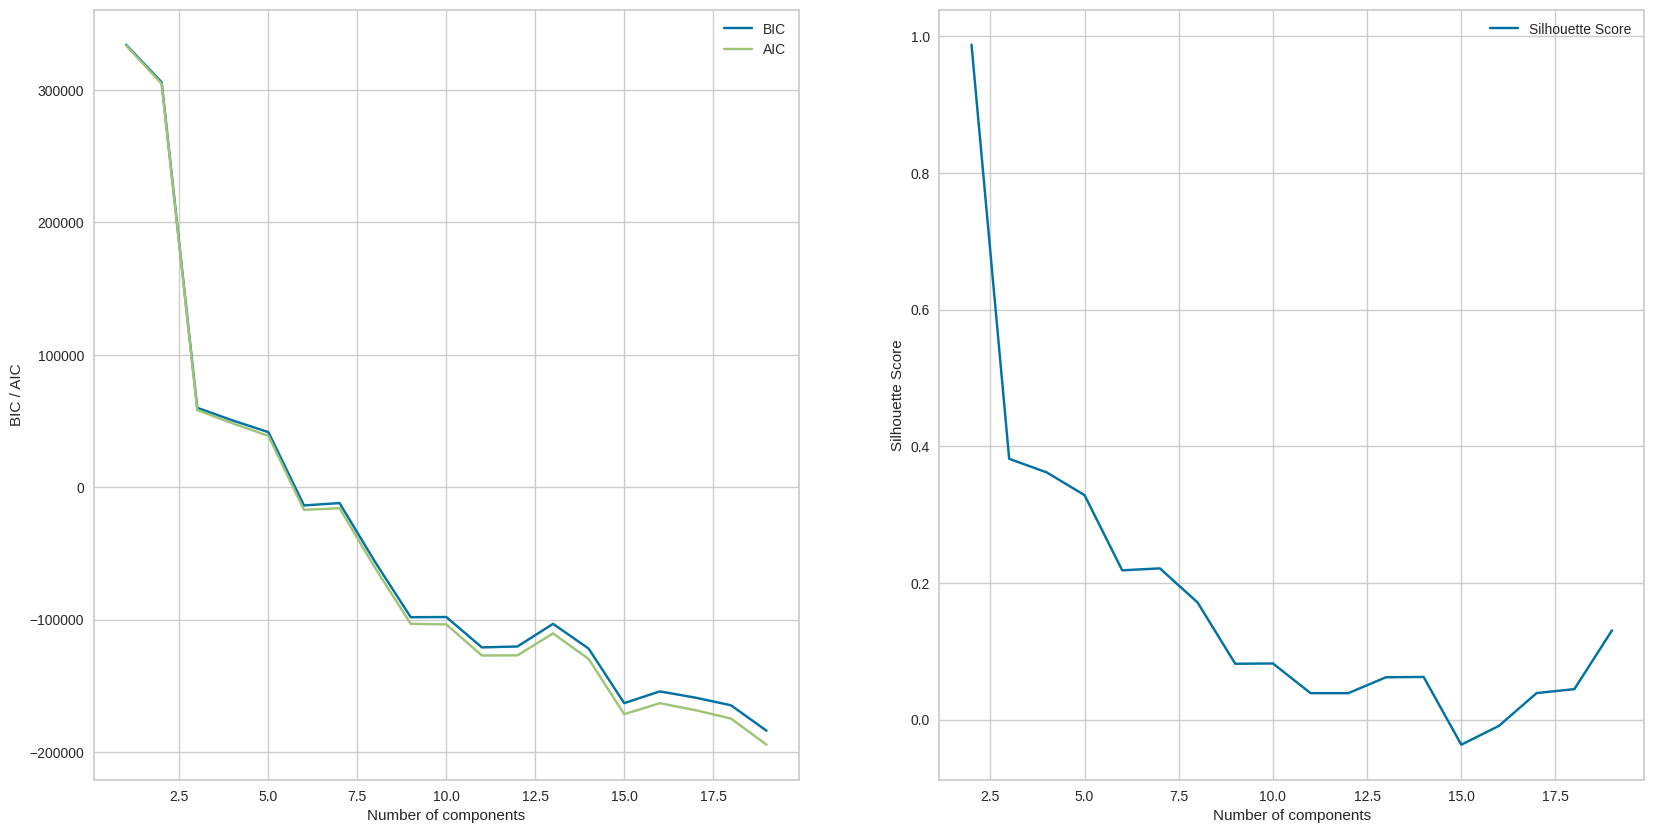

In [ ]:
X = data_pca

n_components = np.arange(1, 20)

bic = []
aic = []
sil_scores = []
for n in n_components:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X)
    bic.append(gmm.bic(X))
    aic.append(gmm.aic(X))
    if n > 1:
        labels = gmm.predict(X)
        sil_scores.append(silhouette_score(X, labels))

# Plot BIC/AIC to find the optimal number of components
plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.plot(n_components, bic, label='BIC')
plt.plot(n_components, aic, label='AIC')
plt.xlabel('Number of components')
plt.ylabel('BIC / AIC')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(n_components[1:], sil_scores, label='Silhouette Score')
plt.xlabel('Number of components')
plt.ylabel('Silhouette Score')
plt.legend()

plt.show()

Optimal number of components (based on BIC): 2
GMM Silhouette Score:  0.9877080938842163
GMM Calinski-Harabasz Score:  5430.742811159437
GMM Davies-Bouldin Score:  0.00843554932333845


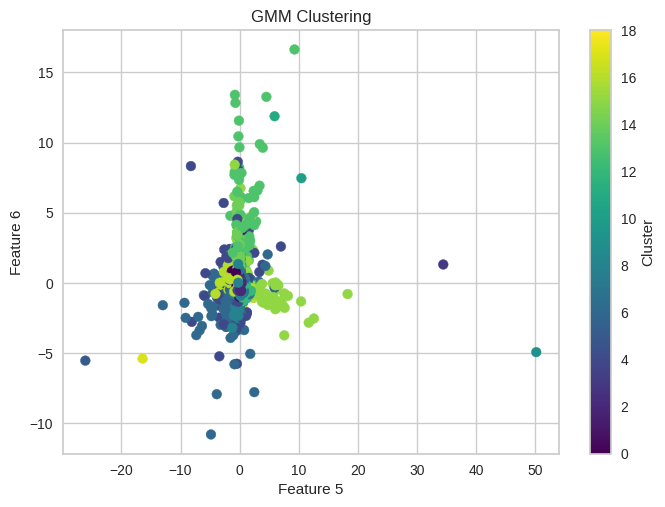

In [ ]:
optimal_n = 2
print(f'Optimal number of components (based on BIC): {optimal_n}')

gmm = GaussianMixture(n_components=optimal_n)
gmm.fit(X)
gmm_labels = gmm.predict(X)


silhouette_avg = silhouette_score(data_pca, gmm_labels)
calinski_harabasz = calinski_harabasz_score(data_pca, gmm_labels)
davies_bouldin = davies_bouldin_score(data_pca, gmm_labels)

print("GMM Silhouette Score: ", silhouette_avg)
print("GMM Calinski-Harabasz Score: ", calinski_harabasz)
print("GMM Davies-Bouldin Score: ", davies_bouldin)


plt.scatter(X[:, 4], X[:, 5], c=labels, cmap='viridis')
plt.xlabel('Feature 5')
plt.ylabel('Feature 6')
plt.title('GMM Clustering')
plt.colorbar(label='Cluster')
plt.show()

### **3.4 DBSCAN after PCA**

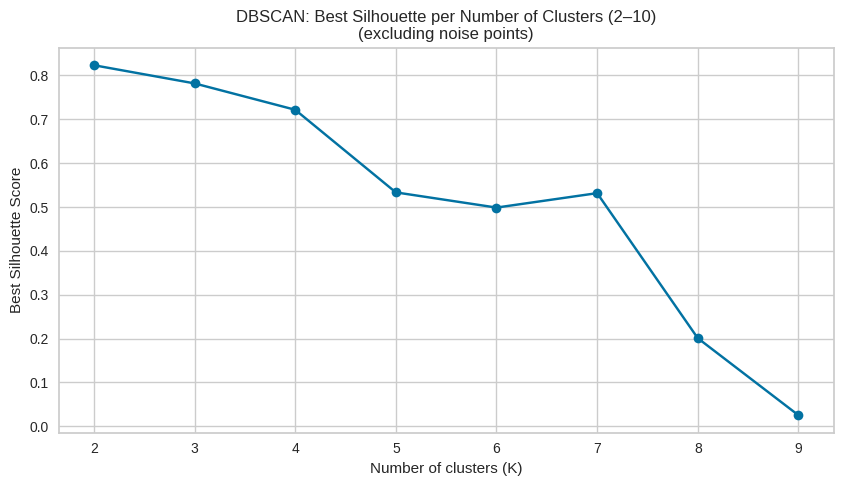

Search complete.
Best overall (excluding noise): {'sil': 0.8231811746432708, 'eps': 3.5535982264407906, 'min_samples': 5, 'n_clusters': 2}
Best params by K (2–10) available in dict: best_params_by_k


In [ ]:
def dbscan_scores_excluding_noise(X, labels):
    mask = labels != -1
    if mask.sum() < 2:
        return np.nan, np.nan, np.nan
    lbl = labels[mask]
    if len(np.unique(lbl)) < 2:
        return np.nan, np.nan, np.nan
    Xc = X[mask]
    sil = silhouette_score(Xc, lbl)
    ch  = calinski_harabasz_score(Xc, lbl)
    db  = davies_bouldin_score(Xc, lbl)
    return sil, ch, db

min_samples_list = [3, 5, 10, 20]
k_for_knn = max(min_samples_list)

nbrs = NearestNeighbors(n_neighbors=k_for_knn).fit(data_pca)
distances, _ = nbrs.kneighbors(data_pca)
k_dists = np.sort(distances[:, -1])

eps_low, eps_high = np.percentile(k_dists, 50), np.percentile(k_dists, 99)
eps_candidates = np.linspace(eps_low, eps_high, 25)

best_overall = {"sil": -1, "eps": None, "min_samples": None, "n_clusters": None}
best_by_k = {k: -1 for k in range(2, 11)}
best_params_by_k = {}
for ms in min_samples_list:
    for eps in eps_candidates:
        db = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1)
        labels = db.fit_predict(data_pca)

        unique_labels = [l for l in np.unique(labels) if l != -1]
        n_clusters = len(unique_labels)
        if n_clusters < 2 or n_clusters > 10:
            continue

        try:
            sil, ch, dbi = dbscan_scores_excluding_noise(data_pca, labels)
        except Exception:
            continue
        if np.isnan(sil):
            continue

        # Track best-per-K
        if sil > best_by_k[n_clusters]:
            best_by_k[n_clusters] = sil
            best_params_by_k[n_clusters] = {"eps": float(eps), "min_samples": int(ms), "sil": float(sil)}

        # Track global best
        if sil > best_overall["sil"]:
            best_overall = {"sil": float(sil), "eps": float(eps), "min_samples": int(ms), "n_clusters": int(n_clusters)}

xs = list(range(2, 11))
ys = [best_by_k[k] if best_by_k[k] != -1 else np.nan for k in xs]

plt.figure(figsize=(10, 5))
plt.plot(xs, ys, marker='o')
plt.title('DBSCAN: Best Silhouette per Number of Clusters (2–10)\n(excluding noise points)')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Best Silhouette Score')
plt.show()

print("Search complete.")
print("Best overall (excluding noise):", best_overall)
print("Best params by K (2–10) available in dict: best_params_by_k")


=== DBSCAN Final Configuration ===
Chosen K (clusters excluding noise): 4 (targeted K=4)
Best eps for K=4: 3.5535982264407906
Best min_samples for K=4: 3
Silhouette (excluding noise): 0.7216
Calinski-Harabasz (excluding noise): 130.37
Davies-Bouldin (excluding noise): 0.5962

Wallets per cluster (excluding noise):
       wallet_count
label              
0              9221
1                 7
2                 3
3                 3

Noise points (label = -1): 79


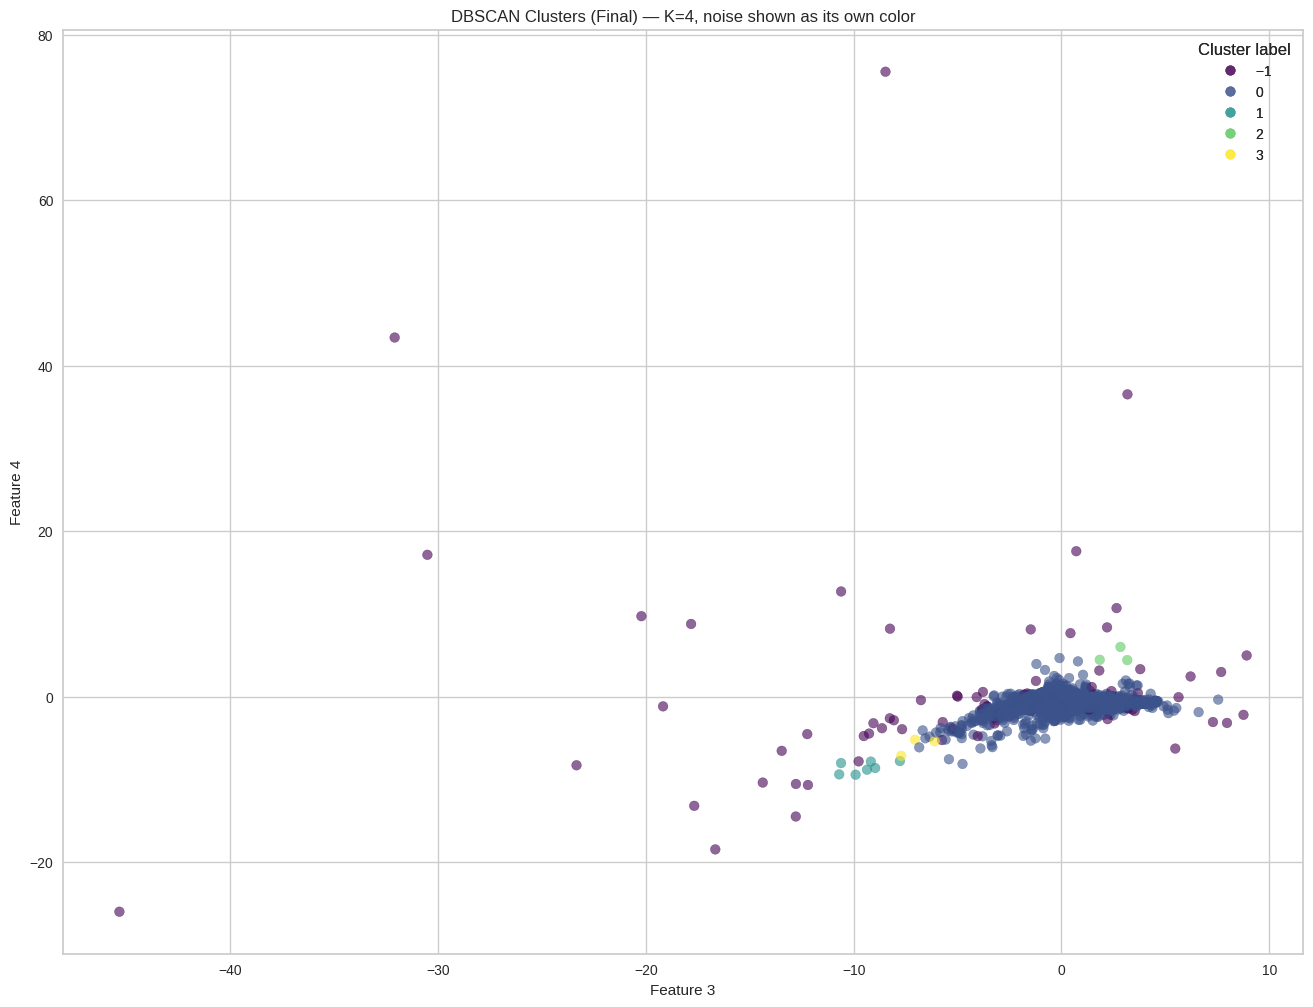

In [ ]:
k_selected = 4
if k_selected not in best_params_by_k:
    if best_overall["n_clusters"] is not None and best_overall["n_clusters"] in best_params_by_k:
        k_selected = best_overall["n_clusters"]
        print(f"Requested K not found. Falling back to best overall K={k_selected}.")
    else:
        available_ks = sorted(best_params_by_k.keys())
        if not available_ks:
            raise ValueError("No valid DBSCAN configurations found for K in [2..10].")
        k_selected = max(available_ks, key=lambda k: best_params_by_k[k]["sil"])
        print(f"Requested K not found. Falling back to best available K={k_selected}.")

params = best_params_by_k[k_selected]
best_dbscan_eps = params["eps"]
best_dbscan_min_samples = params["min_samples"]

db_final = DBSCAN(eps=best_dbscan_eps, min_samples=best_dbscan_min_samples, n_jobs=-1)
dbscan_labels = db_final.fit_predict(data_pca)

dbscan_silhouette, dbscan_calinski, dbscan_davies = dbscan_scores_excluding_noise(data_pca, dbscan_labels)

labels_series = pd.Series(dbscan_labels, name="label")
noise_count = int((labels_series == -1).sum())
cluster_counts = labels_series[labels_series != -1].value_counts().sort_index()
optimal_dbscan_clusters = cluster_counts.shape[0]

print("\n=== DBSCAN Final Configuration ===")
print(f"Chosen K (clusters excluding noise): {optimal_dbscan_clusters} (targeted K={k_selected})")
print(f"Best eps for K={k_selected}: {best_dbscan_eps}")
print(f"Best min_samples for K={k_selected}: {best_dbscan_min_samples}")
print(f"Silhouette (excluding noise): {dbscan_silhouette:.4f}" if pd.notna(dbscan_silhouette) else "Silhouette: NaN")
print(f"Calinski-Harabasz (excluding noise): {dbscan_calinski:.2f}" if pd.notna(dbscan_calinski) else "Calinski-Harabasz: NaN")
print(f"Davies-Bouldin (excluding noise): {dbscan_davies:.4f}" if pd.notna(dbscan_davies) else "Davies-Bouldin: NaN")

print("\nWallets per cluster (excluding noise):")
print(cluster_counts.rename("wallet_count").to_frame())

print(f"\nNoise points (label = -1): {noise_count}")

ix, iy = (2, 3) if data_pca.shape[1] > 3 else (0, 1)
plt.figure(figsize=(16, 12))
scatter = plt.scatter(data_pca[:, ix], data_pca[:, iy], c=dbscan_labels, cmap='viridis', alpha=0.6)
legend1 = plt.legend(*scatter.legend_elements(), title="Cluster label")
plt.gca().add_artist(legend1)
plt.xlabel(f'Feature {ix+1}')
plt.ylabel(f'Feature {iy+1}')
plt.title(f'DBSCAN Clusters (Final) — K={optimal_dbscan_clusters}, noise shown as its own color')
plt.show()


## **4. Deep Learning Based Clustering**

### **4.1 Variational Auto Encoder (VAE) with Classical Clustering**

In [ ]:
from keras import layers, Model, ops, random

input_dim = data_scaled.shape[1]
latent_dim = 2

#Custom sampling layer that also adds KL loss
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        eps = random.normal(shape=ops.shape(z_mean))
        z = z_mean + ops.exp(0.5 * z_log_var) * eps
        kl = -0.5 * ops.sum(1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var), axis=-1)
        self.add_loss(ops.mean(kl))
        return z

# Encoder
inputs = layers.Input(shape=(input_dim,))
h = layers.Dense(64, activation='relu')(inputs)
h = layers.Dense(32, activation='relu')(h)
z_mean = layers.Dense(latent_dim, name="z_mean")(h)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(h)
z = Sampling(name="z")([z_mean, z_log_var])

# Decoder
decoder_h = layers.Dense(32, activation='relu')
decoder_out = layers.Dense(input_dim, activation='linear', name="recon")
h_decoded = decoder_h(z)
x_decoded = decoder_out(h_decoded)

# VAE model
vae = Model(inputs, x_decoded, name="vae")

# Reconstruction loss
def recon_loss(y_true, y_pred):
    return ops.mean(ops.sum(ops.square(y_true - y_pred), axis=-1))

vae.compile(optimizer='adam', loss=recon_loss)

# Train
history = vae.fit(data_scaled, data_scaled, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Encoder to get latent reps for clustering
encoder = Model(inputs, z_mean, name="encoder")
latent_representations_km = encoder.predict(data_scaled, batch_size=512)


Epoch 1/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 20.7258 - val_loss: 54.1669
Epoch 2/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 15.3924 - val_loss: 49.2452
Epoch 3/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 11.8874 - val_loss: 50.8815
Epoch 4/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 14.1022 - val_loss: 49.3498
Epoch 5/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 14.6764 - val_loss: 45.6555
Epoch 6/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 786942.6250 - val_loss: 51.1182
Epoch 7/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 12.9267 - val_loss: 49.1371
Epoch 8/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 10.6181 - val_loss: 47.9909
Epoch 9/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 12.5960 - val_loss: 47.2222
Epoch 10/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9.4416 - val_loss: 47.8178
Epoch 11/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 11.5082 - val_loss: 45.5183
Epoch 12/50
233/233 ━━━━━━━

####**4.1.1 VAE + K-Means**

292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


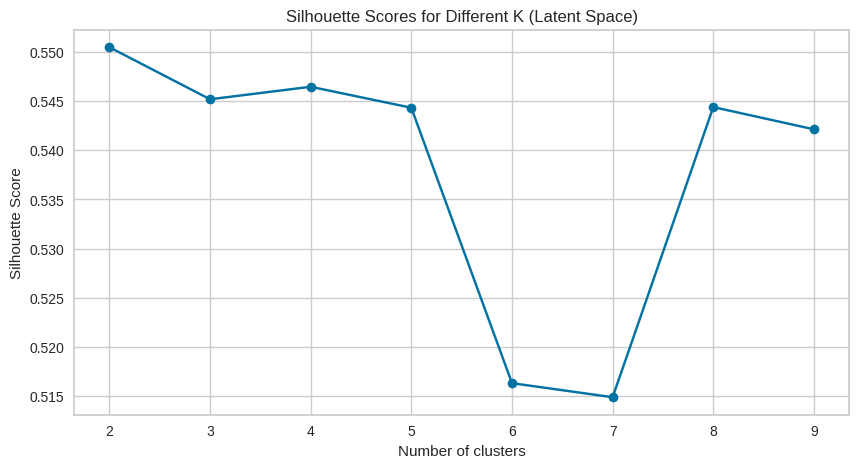

In [ ]:
# Encoder model to extract latent representations
encoder = Model(inputs, z_mean)

# Get the latent representations
latent_representations_km = encoder.predict(data_scaled)

silhouette_scores = []
max_clusters = 10

for i in range(2, max_clusters):
    kmeans = KMeans(n_clusters=i, random_state=0)
    labels = kmeans.fit_predict(latent_representations_km)
    silhouette_scores.append(silhouette_score(latent_representations_km, labels))

plt.figure(figsize=(10, 5))
plt.plot(range(2, max_clusters), silhouette_scores, marker='o')
plt.title('Silhouette Scores for Different K (Latent Space)')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


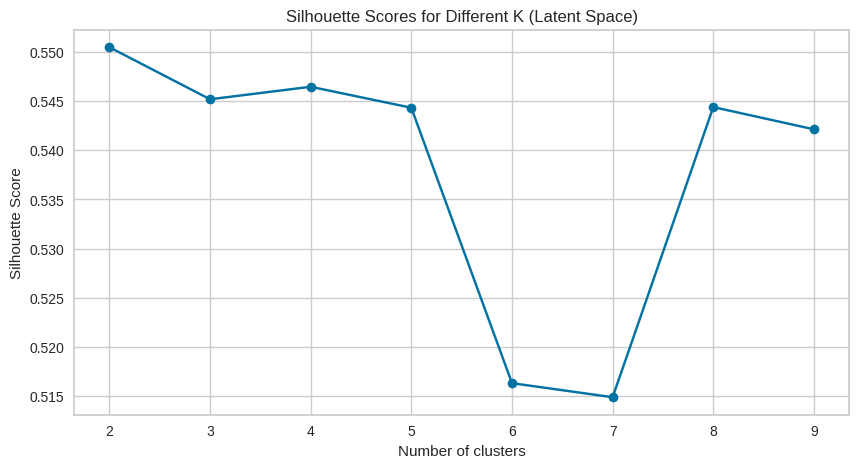

Best K (latent space): 2
Silhouette Score: 0.5505
Davies-Bouldin Index: 0.8583
Calinski-Harabasz Index: 2731.36

Cluster Counts:
  Cluster 0: 7292 samples
  Cluster 1: 2021 samples


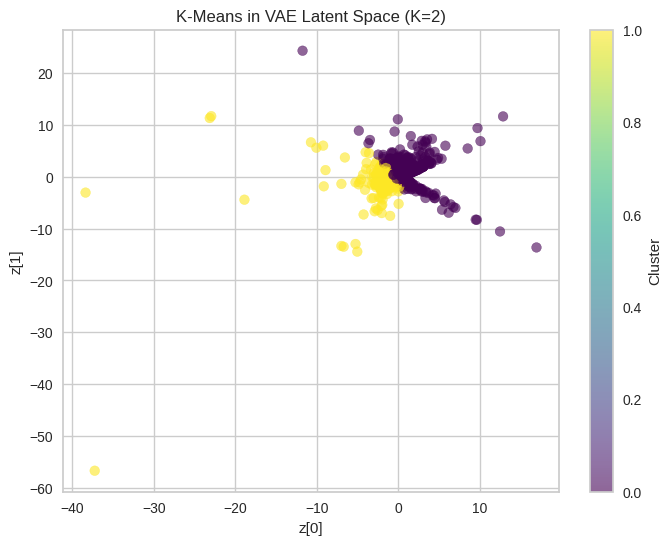

In [ ]:
latent_representations_km = encoder.predict(data_scaled, batch_size=512)

silhouette_scores = []
max_clusters = 10

for i in range(2, max_clusters):
    kmeans = KMeans(n_clusters=i, random_state=0)
    labels = kmeans.fit_predict(latent_representations_km)
    silhouette_scores.append(silhouette_score(latent_representations_km, labels))

plt.figure(figsize=(10, 5))
plt.plot(range(2, max_clusters), silhouette_scores, marker='o')
plt.title('Silhouette Scores for Different K (Latent Space)')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

optimal_k = 2 + int(np.argmax(silhouette_scores))
kmeans = KMeans(n_clusters=optimal_k, random_state=0)
cluster_labels_km = kmeans.fit_predict(latent_representations_km)

silhouette_dl_kmeans = silhouette_score(latent_representations_km, cluster_labels_km)
dbdlkmeans = davies_bouldin_score(latent_representations_km, cluster_labels_km)
chdlkmeans = calinski_harabasz_score(latent_representations_km, cluster_labels_km)

print(f"Best K (latent space): {optimal_k}")
print(f"Silhouette Score: {silhouette_dl_kmeans:.4f}")
print(f"Davies-Bouldin Index: {dbdlkmeans:.4f}")
print(f"Calinski-Harabasz Index: {chdlkmeans:.2f}")

from collections import Counter
counts = Counter(cluster_labels_km)
print("\nCluster Counts:")
for c, n in sorted(counts.items()):
    print(f"  Cluster {c}: {n} samples")

if latent_representations_km.shape[1] >= 2:
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(latent_representations_km[:, 0], latent_representations_km[:, 1],
                     c=cluster_labels_km, cmap='viridis', alpha=0.6)
    plt.colorbar(sc, label='Cluster')
    plt.xlabel('z[0]'); plt.ylabel('z[1]')
    plt.title(f'K-Means in VAE Latent Space (K={optimal_k})')
    plt.show()

#### **4.1.2 VAE + GMM**

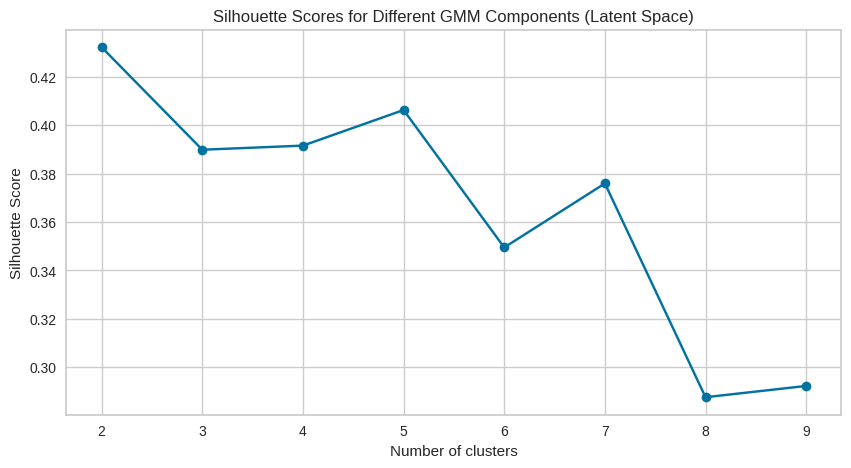

In [ ]:
gmm_silhouette_scores = []

for i in range(2, max_clusters):
    gmm = GaussianMixture(n_components=i, random_state=0)
    gmm_labels = gmm.fit_predict(latent_representations_km)
    gmm_silhouette_scores.append(silhouette_score(latent_representations_km, gmm_labels))

plt.figure(figsize=(10, 5))
plt.plot(range(2, max_clusters), gmm_silhouette_scores, marker='o')
plt.title('Silhouette Scores for Different GMM Components (Latent Space)')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [ ]:
optimal_gmm_k = 2

# Fit GMM
gmm = GaussianMixture(n_components=optimal_gmm_k, random_state=0)
gmm_labels = gmm.fit_predict(latent_representations_km)

# Evaluation metrics
gmm_silhouette_avg = silhouette_score(latent_representations_km, gmm_labels)
dbdlgmm = davies_bouldin_score(latent_representations_km, gmm_labels)
chdlgmm = calinski_harabasz_score(latent_representations_km, gmm_labels)

# Cluster counts
cluster_counts_gmm = Counter(gmm_labels)

# Print results
print(f"Silhouette Score for GMM with {optimal_gmm_k} clusters in latent space: {gmm_silhouette_avg:.4f}")
print(f"Davies-Bouldin Score for GMM with {optimal_gmm_k} clusters in latent space: {dbdlgmm:.4f}")
print(f"Calinski-Harabasz Score for GMM with {optimal_gmm_k} clusters in latent space: {chdlgmm:.4f}")
print("\nCluster Counts:")
for cluster, count in sorted(cluster_counts_gmm.items()):
    print(f"  Cluster {cluster}: {count} samples")

Silhouette Score for GMM with 2 clusters in latent space: 0.4322
Davies-Bouldin Score for GMM with 2 clusters in latent space: 1.5891
Calinski-Harabasz Score for GMM with 2 clusters in latent space: 1073.5603

Cluster Counts:
  Cluster 0: 5788 samples
  Cluster 1: 3525 samples


#### **4.1.3 VAE + Agglomerative Clustering**

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


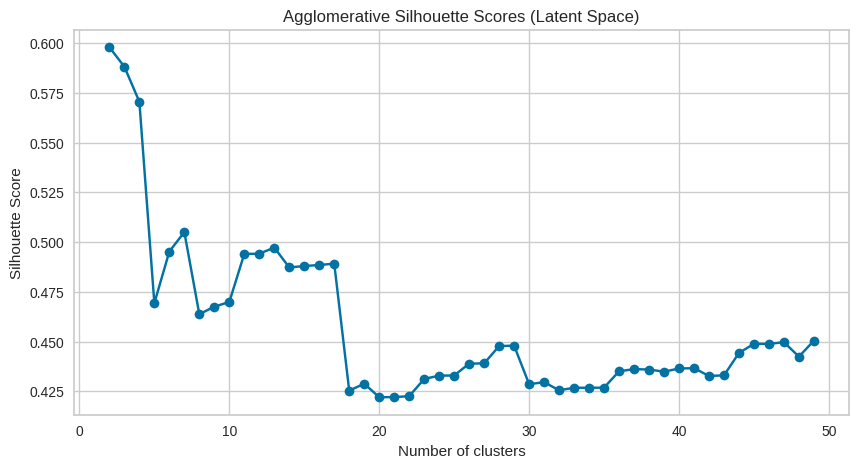

Best K (Agglomerative, latent space): 2
Silhouette Score: 0.5979
Calinski-Harabasz Index: 2073.19
Davies-Bouldin Index: 0.7224

Cluster Counts:
  Cluster 0: 748 samples
  Cluster 1: 8565 samples


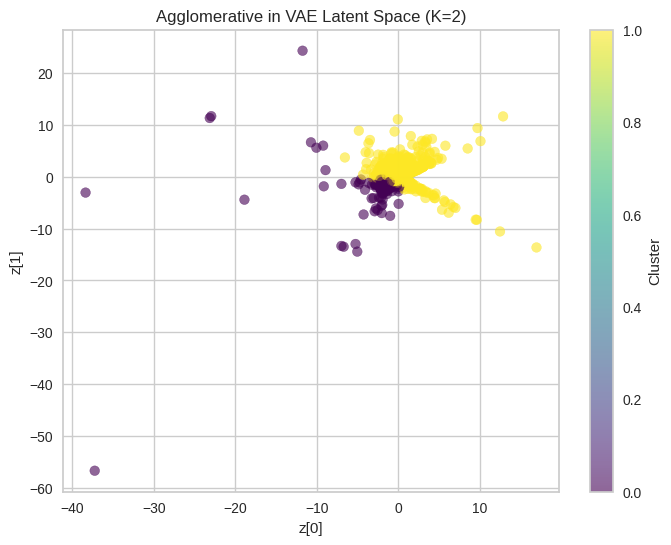

In [ ]:
latent = encoder.predict(data_scaled, batch_size=512)

max_clusters = 50
silhouette_scores_ag = []

for k in range(2, max_clusters):
    ag = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = ag.fit_predict(latent)
    silhouette_scores_ag.append(silhouette_score(latent, labels))

plt.figure(figsize=(10, 5))

plt.plot(range(2, max_clusters), silhouette_scores_ag, marker='o')
plt.title('Agglomerative Silhouette Scores (Latent Space)')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

optimal_k_ag = 2 + int(np.argmax(silhouette_scores_ag))
agg = AgglomerativeClustering(n_clusters=optimal_k_ag, linkage='ward')
labels_ag = agg.fit_predict(latent)

ag_sil = silhouette_score(latent, labels_ag)
ag_ch = calinski_harabasz_score(latent, labels_ag)
ag_db = davies_bouldin_score(latent, labels_ag)
counts_ag = Counter(labels_ag)

print(f"Best K (Agglomerative, latent space): {optimal_k_ag}")
print(f"Silhouette Score: {ag_sil:.4f}")
print(f"Calinski-Harabasz Index: {ag_ch:.2f}")
print(f"Davies-Bouldin Index: {ag_db:.4f}")
print("\nCluster Counts:")
for c, n in sorted(counts_ag.items()):
    print(f"  Cluster {c}: {n} samples")

if latent.shape[1] >= 2:
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(latent[:, 0], latent[:, 1], c=labels_ag, cmap='viridis', alpha=0.6)
    plt.colorbar(sc, label='Cluster')
    plt.xlabel('z[0]'); plt.ylabel('z[1]')
    plt.title(f'Agglomerative in VAE Latent Space (K={optimal_k_ag})')
    plt.show()

#### **4.1.4 VAE + DBSCAN**

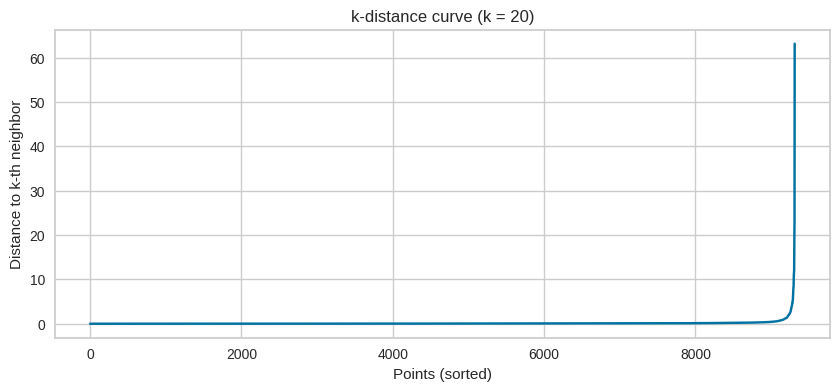

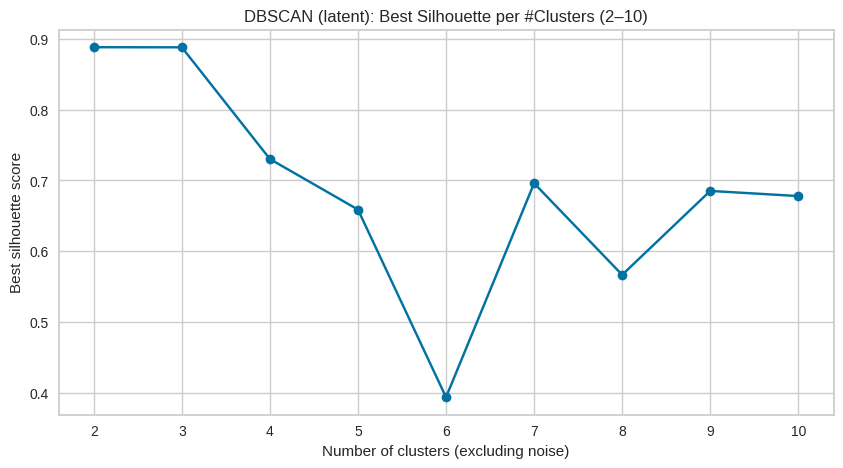

Recommended (eps, min_samples) per #clusters (NaN means not found):


,clusters,eps*,min_samples*,best_silhouette
0,2,1.498494,3,0.888451
1,3,1.632007,3,0.888331
2,4,0.964443,3,0.730374
3,5,0.563904,5,0.658872
4,6,0.230122,5,0.393543
5,7,0.897686,3,0.696066
6,8,0.363635,3,0.566587
7,9,0.764174,3,0.685264
8,10,0.697417,3,0.677972


In [ ]:
try:
    latent = latent_representations_km
except NameError:
    latent = encoder.predict(data_scaled, batch_size=512)

min_samples_list = [3, 5, 10, 20]
k_for_knn = max(min_samples_list)

nbrs = NearestNeighbors(n_neighbors=k_for_knn).fit(latent)
distances, _ = nbrs.kneighbors(latent)
k_dists = np.sort(distances[:, -1])

plt.figure(figsize=(10, 4))
plt.plot(k_dists)
plt.title(f'k-distance curve (k = {k_for_knn})')
plt.xlabel('Points (sorted)')
plt.ylabel('Distance to k-th neighbor')
plt.grid(True)
plt.show()

eps_low, eps_high = np.percentile(k_dists, 50), np.percentile(k_dists, 99)
eps_candidates = np.linspace(eps_low, eps_high, 25)

best_sil_by_k = {k: -1 for k in range(2, 11)}
best_cfg_by_k = {k: None for k in range(2, 11)}
dbscan_grid = []

for ms in min_samples_list:
    for eps in eps_candidates:
        db = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1)
        labels = db.fit_predict(latent)
        uniq = [c for c in np.unique(labels) if c != -1]
        n_clusters = len(uniq)
        if not (2 <= n_clusters <= 10):
            continue
        try:
            sil = silhouette_score(latent, labels)
        except Exception:
            continue
        dbscan_grid.append({"eps": float(eps), "min_samples": int(ms),
                            "n_clusters": int(n_clusters), "silhouette": sil})
        if sil > best_sil_by_k[n_clusters]:
            best_sil_by_k[n_clusters] = sil
            best_cfg_by_k[n_clusters] = {"eps": float(eps), "min_samples": int(ms), "silhouette": sil}

xs = list(range(2, 11))
ys = [best_sil_by_k[k] if best_sil_by_k[k] != -1 else np.nan for k in xs]
plt.figure(figsize=(10, 5))
plt.plot(xs, ys, marker='o')
plt.title('DBSCAN (latent): Best Silhouette per #Clusters (2–10)')
plt.xlabel('Number of clusters (excluding noise)')
plt.ylabel('Best silhouette score')
plt.grid(True)
plt.show()

summary_rows = []
for k in xs:
    cfg = best_cfg_by_k[k]
    summary_rows.append([k,
                         None if cfg is None else cfg["eps"],
                         None if cfg is None else cfg["min_samples"],
                         None if cfg is None else cfg["silhouette"]])
summary_df = pd.DataFrame(summary_rows, columns=["clusters", "eps*", "min_samples*", "best_silhouette"])
print("Recommended (eps, min_samples) per #clusters (NaN means not found):")
display(summary_df)

Running DBSCAN with eps=1.632007, min_samples=3 for target 3 clusters...
Clusters (excluding noise): 3
Silhouette: 0.8883 | Calinski-Harabasz: 228.18 | Davies-Bouldin: 2.8591
Cluster Counts (excluding noise): {np.int64(0): 9281, np.int64(1): 4, np.int64(2): 3}


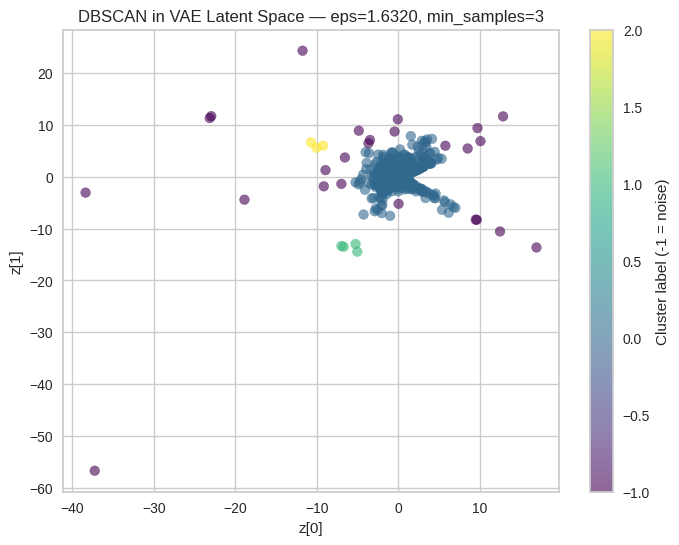

In [ ]:
k_selected = 3
cfg = best_cfg_by_k.get(k_selected)
if cfg is None:
    raise ValueError(f"No DBSCAN config found that produced {k_selected} clusters in the search range.")

eps = cfg["eps"]
min_samples = cfg["min_samples"]

print(f"Running DBSCAN with eps={eps:.6f}, min_samples={min_samples} for target {k_selected} clusters...")

db = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
dbscan_labels = db.fit_predict(latent)

uniq = np.unique(dbscan_labels)
n_clusters_final = len([c for c in uniq if c != -1])

if n_clusters_final < 2:
    dbscan_silhouette = np.nan
    dbscan_calinski = np.nan
    dbscan_davies = np.nan
else:
    dbscan_silhouette = silhouette_score(latent, dbscan_labels)
    dbscan_calinski = calinski_harabasz_score(latent, dbscan_labels)
    dbscan_davies = davies_bouldin_score(latent, dbscan_labels)

print(f"Clusters (excluding noise): {n_clusters_final}")
print(f"Silhouette: {dbscan_silhouette:.4f} | Calinski-Harabasz: {dbscan_calinski:.2f} | Davies-Bouldin: {dbscan_davies:.4f}")

counts = Counter(dbscan_labels)
counts_no_noise = {k: v for k, v in counts.items() if k != -1}
print("Cluster Counts (excluding noise):", counts_no_noise)

if latent.shape[1] >= 2:
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(latent[:, 0], latent[:, 1], c=dbscan_labels, cmap='viridis', alpha=0.6)
    plt.colorbar(sc, label='Cluster label (-1 = noise)')
    plt.xlabel('z[0]'); plt.ylabel('z[1]')
    plt.title(f'DBSCAN in VAE Latent Space — eps={eps:.4f}, min_samples={min_samples}')
    plt.show()

### **4.2 Deep InfoMax Clustering**

In [ ]:
class DeepInfoMax(pl.LightningModule):
    def __init__(self, input_dim, latent_dim):
        super(DeepInfoMax, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, latent_dim)
        )
        self.discriminator = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        return z

    def training_step(self, batch, batch_idx):
        x = batch[0]
        z = self.encoder(x)
        pos = self.discriminator(z)
        neg = self.discriminator(torch.roll(z, 1, 0))

        pos_loss = -torch.log(pos + 1e-6).mean()
        neg_loss = -torch.log(1 - neg + 1e-6).mean()

        loss = pos_loss + neg_loss
        self.log('train_loss', loss)
        return loss

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=1e-3, weight_decay=1e-5)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor': 'train_loss',
            }
        }

    def on_before_zero_grad(self, optimizer):
        # Gradient clipping to avoid exploding gradients
        torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=1.0)

In [ ]:
# Convert data to PyTorch tensors
X_tensor = torch.tensor(data_scaled, dtype=torch.float32)
dataset = TensorDataset(X_tensor)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# Define model
input_dim = data_scaled.shape[1]
latent_dim = 10
model = DeepInfoMax(input_dim, latent_dim)

# Train model
trainer = pl.Trainer(max_epochs=10)
trainer.fit(model, dataloader)

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name          | Type       | Params | Mode 
-----------------------------------------------------
0 | encoder       | Sequential | 151 K  | train
1 | discriminator | Sequential | 136 K  | train
-----------------------------------------------------
288 K     Trainable params
0         Non-trainable params
288 K     Total params
1.153     Total estimated model params size (MB)
20        Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


In [ ]:
# Get the learned representations
model.eval()
with torch.no_grad():
    z = model.encoder(X_tensor).numpy()

results = []

for n_clusters in range(2, 21):
    kmeans = KMeans(n_clusters=n_clusters)
    clusters = kmeans.fit_predict(z)

    silhouette_avg = silhouette_score(z, clusters)
    davies_bouldin = davies_bouldin_score(z, clusters)
    calinski_harabasz = calinski_harabasz_score(z, clusters)

    results.append({
        'n_clusters': n_clusters,
        'silhouette_score': silhouette_avg,
        'davies_bouldin_index': davies_bouldin,
        'calinski_harabasz_index': calinski_harabasz
    })

results_df = pd.DataFrame(results)

print(results_df)

    n_clusters  silhouette_score  davies_bouldin_index  \
0            2          0.995107              0.003859   
1            3          0.967782              0.299365   
2            4          0.885005              0.358594   
3            5          0.874293              0.433330   
4            6          0.869510              0.425301   
5            7          0.822831              0.480800   
6            8          0.806488              0.516085   
7            9          0.805386              0.511455   
8           10          0.802102              0.517557   
9           11          0.802945              0.518654   
10          12          0.760417              0.565965   
11          13          0.763991              0.591466   
12          14          0.763308              0.597537   
13          15          0.766569              0.510885   
14          16          0.767686              0.570069   
15          17          0.706709              0.700996   
16          18

In [ ]:
model.eval()
with torch.no_grad():
    z = model.encoder(X_tensor).numpy()

n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters)
clusters_dim1 = kmeans.fit_predict(z)

data_scaled_with_clusters = np.hstack((data_scaled, clusters_dim1.reshape(-1, 1)))

column_names = [f'feature_{i}' for i in range(data_scaled.shape[1])] + ['cluster']
df_clusters = pd.DataFrame(data_scaled_with_clusters, columns=column_names)

In [ ]:
silhouette_avg = silhouette_score(z, clusters_dim1)
davies_bouldin = davies_bouldin_score(z, clusters_dim1)
calinski_harabasz = calinski_harabasz_score(z, clusters_dim1)

cluster_counts = Counter(clusters_dim1)

print(f"Silhouette Score: {silhouette_avg:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin:.4f}")
print(f"Calinski-Harabasz Index: {calinski_harabasz:.4f}")
print("\nCluster Counts:")
for cluster, count in sorted(cluster_counts.items()):
    print(f"  Cluster {cluster}: {count} samples")

Silhouette Score: 0.8942
Davies-Bouldin Index: 0.5303
Calinski-Harabasz Index: 16325.4326

Cluster Counts:
  Cluster 0: 18769 samples
  Cluster 1: 10 samples
  Cluster 2: 796 samples


In [ ]:
df['cluster_dim1'] = clusters_dim1

label_col = 'cluster_dim1'
id_col = 'address'

feature_cols = [c for c in df.columns
                if c not in {id_col, label_col} and pd.api.types.is_numeric_dtype(df[c])]

print(f"✅ Attached {label_col} to df with {df[label_col].nunique()} unique clusters")
print(f"Features used for analysis: {len(feature_cols)}")


✅ Attached cluster_dim1 to df with 3 unique clusters
Features used for analysis: 31


**Download the Dataframe with the Cluster Labels**

In [ ]:
# Save as CSV
df.to_csv("bull.csv", index=False)

# For Colab: download to your local machine
from google.colab import files
files.download("bull.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Intra-Cluster Analysis**

Cluster sizes:
0    19526
1        3
2       46

Overall silhouette: 0.924
Mean silhouette by cluster:
0    0.927
1   -0.390
2   -0.241

Top features by ANOVA F-test:
          feature           F   p
  max_tx_value_in 6330.224133 0.0
 tx_value_in_mean 6005.456288 0.0
 max_tx_value_out 4912.551493 0.0
tx_value_out_mean 4813.761426 0.0
     tok_count_in 4603.982308 0.0
  trace_count_out 4463.836183 0.0
     tx_count_out 4463.836183 0.0
         total_tx 4436.697492 0.0
     gas_used_sum 4401.548256 0.0
    tok_count_out 4359.199299 0.0


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [18 19] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



Top features by permutation importance:
          feature  importance_mean  importance_std
  max_tx_value_in         0.213952        0.002399
  tx_value_in_sum         0.209464        0.004797
 tx_value_out_sum         0.165051        0.011925
  tok_entropy_out         0.142875        0.045418
tx_value_out_mean         0.080559        0.002353
 max_tx_value_out         0.069857        0.001248
 tx_value_in_mean         0.040494        0.004836
      betweenness         0.008971        0.002709
       out_degree         0.008709        0.002276
   deg_centrality         0.006924        0.001276

Cluster profile deviations (z-score):

Cluster 0 (n=19526, silhouette=0.927)
High: mean_tx_interval_out (+0.00), is_miner (+0.00), is_contract (+0.00), active_days_out (-0.00), tok_entropy_in (-0.00)
Low : max_tx_value_in (-0.03), tx_value_in_mean (-0.03), min_tx_value_in (-0.03), tx_value_in_sum (-0.02), deg_centrality (-0.02)

Cluster 1 (n=3, silhouette=-0.390)
High: max_tx_value_out (+46.63)

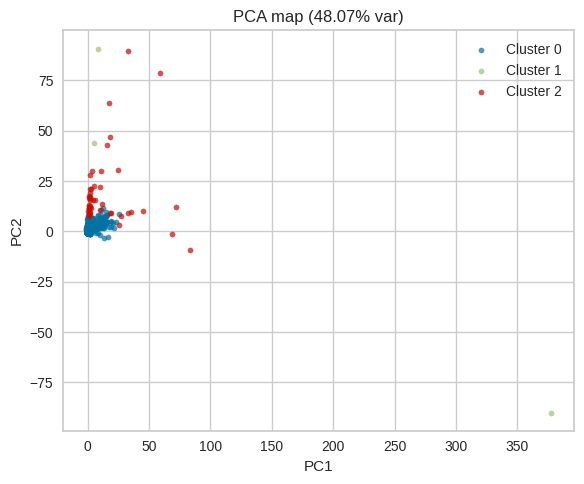

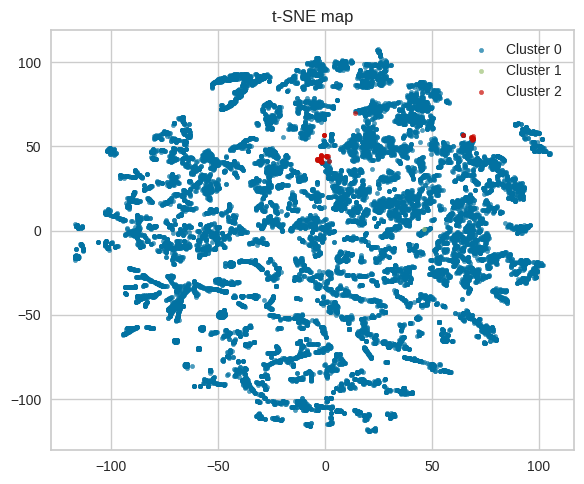

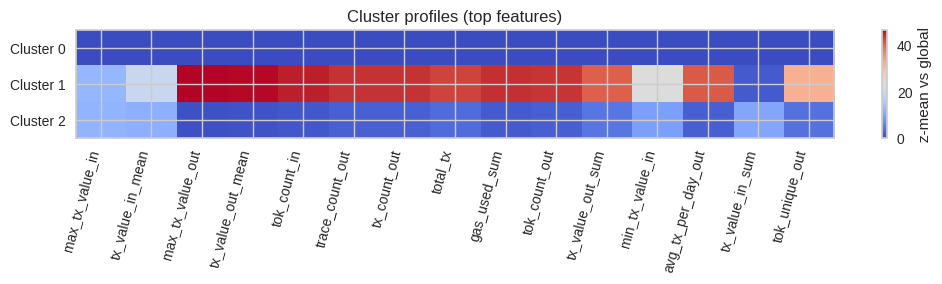


Decision tree rules (on standardized features):
|--- tx_value_in_mean <= 9.40
|   |--- total_tx <= 5.50
|   |   |--- out_degree <= 9.73
|   |   |   |--- max_tx_value_in <= 7.37
|   |   |   |   |--- class: 0
|   |   |   |--- max_tx_value_in >  7.37
|   |   |   |   |--- class: 0
|   |   |--- out_degree >  9.73
|   |   |   |--- class: 2
|   |--- total_tx >  5.50
|   |   |--- class: 2
|--- tx_value_in_mean >  9.40
|   |--- gas_used_sum <= -0.03
|   |   |--- class: 2
|   |--- gas_used_sum >  -0.03
|   |   |--- class: 2



In [ ]:
id_col = 'address'
label_col = 'cluster_dim1'
top_k = 15
random_state = 0

feature_cols = [c for c in df.columns
                if c not in {id_col, label_col} and pd.api.types.is_numeric_dtype(df[c])]

work = df[[id_col, label_col] + feature_cols].copy()
y = work[label_col].values
X = work[feature_cols].astype(float).replace([np.inf, -np.inf], np.nan).fillna(0.0).values
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

cluster_order = sorted(pd.Series(y).unique())
sizes = pd.Series(y).value_counts().reindex(cluster_order)
sil_vals = silhouette_samples(Xz, y)
sil_score = silhouette_score(Xz, y)
sil_by_cluster = pd.Series({c: sil_vals[y==c].mean() for c in cluster_order})

print("Cluster sizes:")
print(sizes.to_string())
print(f"\nOverall silhouette: {sil_score:.3f}")
print("Mean silhouette by cluster:")
print(sil_by_cluster.round(3).to_string())

F, p = f_classif(X, y)
anova_tbl = pd.DataFrame({'feature': feature_cols, 'F': F, 'p': p}).sort_values('F', ascending=False)
print("\nTop features by ANOVA F-test:")
print(anova_tbl.head(10).to_string(index=False))

clf = RandomForestClassifier(n_estimators=400, random_state=random_state, class_weight='balanced_subsample')
clf.fit(Xz, y)
pi = permutation_importance(clf, Xz, y, scoring='f1_macro', n_repeats=15, random_state=random_state)
perm_tbl = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': pi.importances_mean,
    'importance_std': pi.importances_std
}).sort_values('importance_mean', ascending=False)
print("\nTop features by permutation importance:")
print(perm_tbl.head(10).to_string(index=False))

z_df = pd.DataFrame(Xz, columns=feature_cols)
z_df[label_col] = y
zmeans = z_df.groupby(label_col)[feature_cols].mean().loc[cluster_order]

print("\nCluster profile deviations (z-score):")
for c in cluster_order:
    hi = zmeans.loc[c].sort_values(ascending=False).head(5)
    lo = zmeans.loc[c].sort_values(ascending=True).head(5)
    print(f"\nCluster {c} (n={int(sizes[c])}, silhouette={sil_by_cluster[c]:.3f})")
    print("High:", ", ".join([f"{f} ({v:+.2f})" for f,v in hi.items()]))
    print("Low :", ", ".join([f"{f} ({v:+.2f})" for f,v in lo.items()]))

pca = PCA(n_components=2, random_state=random_state)
X2 = pca.fit_transform(Xz)
plt.figure(figsize=(6,5))
for c in cluster_order:
    m = (y==c)
    plt.scatter(X2[m,0], X2[m,1], s=14, alpha=0.7, label=f"Cluster {c}")
plt.title(f"PCA map ({pca.explained_variance_ratio_.sum():.2%} var)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(); plt.tight_layout(); plt.show()

ts = TSNE(n_components=2, init='pca', random_state=random_state, perplexity=30)
Xts = ts.fit_transform(Xz)
plt.figure(figsize=(6,5))
for c in cluster_order:
    m = (y==c)
    plt.scatter(Xts[m,0], Xts[m,1], s=10, alpha=0.7, label=f"Cluster {c}")
plt.title("t-SNE map")
plt.legend(); plt.tight_layout(); plt.show()

top_feats = anova_tbl.head(top_k)['feature'].tolist()
hm = zmeans[top_feats]
plt.figure(figsize=(0.5*len(top_feats)+3, 3))
plt.imshow(hm.values, aspect='auto', cmap='coolwarm')
plt.yticks(range(len(cluster_order)), [f"Cluster {c}" for c in cluster_order])
plt.xticks(range(len(top_feats)), top_feats, rotation=75, ha='right')
plt.colorbar(label="z-mean vs global")
plt.title("Cluster profiles (top features)")
plt.tight_layout(); plt.show()

tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=random_state)
tree.fit(Xz, y)
print("\nDecision tree rules (on standardized features):")
print(export_text(tree, feature_names=feature_cols))

### **4.3 Deep Embedded Clustering**

Epoch 1/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6054 - val_loss: 1.9879
Epoch 2/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5802 - val_loss: 1.9662
Epoch 3/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4532 - val_loss: 1.9487
Epoch 4/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4542 - val_loss: 1.9411
Epoch 5/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4262 - val_loss: 1.9348
Epoch 6/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5995 - val_loss: 1.9297
Epoch 7/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3591 - val_loss: 1.9286
Epoch 8/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5911 - val_loss: 1.9284
Epoch 9/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4728 - val_loss: 1.9276
Epoch 10/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4363 - val_loss: 1.9233
Epoch 11/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3164 - val_loss: 1.9227
Epoch 12/200
117/117 ━━━━━━━━━━━━━━━━━━━━

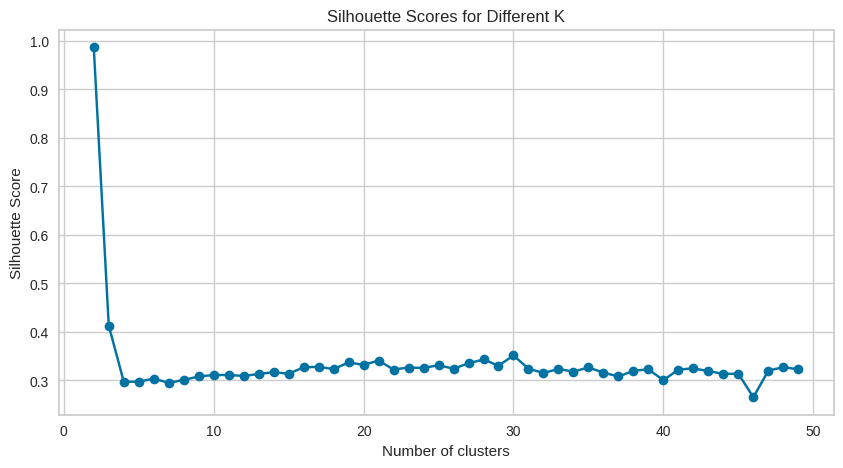

In [ ]:
# Autoencoder parameters
input_dim = data_scaled.shape[1]
latent_dim = 10

# Encoder
inputs = Input(shape=(input_dim,))
h = Dense(64)(inputs)
h = LeakyReLU()(h)
h = Dense(32)(h)
h = LeakyReLU()(h)
latent = Dense(latent_dim)(h)

# Decoder
h_decoded = Dense(32)(latent)
h_decoded = LeakyReLU()(h_decoded)
h_decoded = Dense(64)(h_decoded)
h_decoded = LeakyReLU()(h_decoded)
outputs = Dense(input_dim, activation='sigmoid')(h_decoded)

# Autoencoder model
autoencoder = Model(inputs, outputs)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(data_scaled, data_scaled, epochs=200, batch_size=64, validation_split=0.2)

encoder = Model(inputs, latent)

latent_representations = encoder.predict(data_scaled)

silhouette_scores = []
for i in range(2, max_clusters):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    labels = kmeans.fit_predict(latent_representations)
    silhouette_scores.append(silhouette_score(latent_representations, labels))

plt.figure(figsize=(10, 5))
plt.plot(range(2, max_clusters), silhouette_scores, marker='o')
plt.title('Silhouette Scores for Different K')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()



In [ ]:
pip install keras-deep-clustering


ERROR: Could not find a version that satisfies the requirement keras-deep-clustering (from versions: none)
ERROR: No matching distribution found for keras-deep-clustering


Epoch 1/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7441 - val_loss: 1.9733
Epoch 2/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4499 - val_loss: 1.9454
Epoch 3/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6110 - val_loss: 1.9356
Epoch 4/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5087 - val_loss: 1.9314
Epoch 5/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3966 - val_loss: 1.9306
Epoch 6/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3505 - val_loss: 1.9283
Epoch 7/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4020 - val_loss: 1.9274
Epoch 8/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4142 - val_loss: 1.9267
Epoch 9/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4416 - val_loss: 1.9256
Epoch 10/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5024 - val_loss: 1.9245
Epoch 11/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4266 - val_loss: 1.9239
Epoch 12/200
117/117 ━━━━━━━━━━━━━━━━━━━━

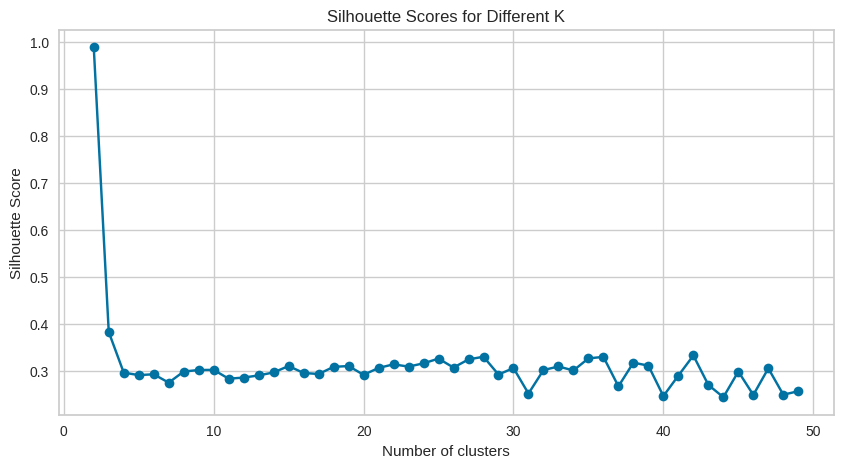

In [ ]:
input_dim = data_scaled.shape[1]
latent_dim = 10

# Encoder
inputs = Input(shape=(input_dim,))
h = Dense(64)(inputs)
h = LeakyReLU()(h)
h = Dense(32)(h)
h = LeakyReLU()(h)
latent = Dense(latent_dim)(h)

# Decoder
h_decoded = Dense(32)(latent)
h_decoded = LeakyReLU()(h_decoded)
h_decoded = Dense(64)(h_decoded)
h_decoded = LeakyReLU()(h_decoded)
outputs = Dense(input_dim, activation='sigmoid')(h_decoded)

# Autoencoder model
autoencoder = Model(inputs, outputs)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(data_scaled, data_scaled, epochs=200, batch_size=64, validation_split=0.2)

encoder = Model(inputs, latent)

latent_representations = encoder.predict(data_scaled)

silhouette_scores = []

for i in range(2, max_clusters):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    labels = kmeans.fit_predict(latent_representations)
    silhouette_scores.append(silhouette_score(latent_representations, labels))

plt.figure(figsize=(10, 5))
plt.plot(range(2, max_clusters), silhouette_scores, marker='o')
plt.title('Silhouette Scores for Different K')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [ ]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=0)
kmeans.fit(latent_representations)
initial_cluster_centers = kmeans.cluster_centers_

### **4.4 Self Organizing Maps**

In [ ]:
som_x, som_y = 10, 10
n_iter = 10000

som = MiniSom(x=som_x, y=som_y, input_len=data_scaled.shape[1], sigma=1.0, learning_rate=0.5, neighborhood_function='gaussian')

som.random_weights_init(data_scaled)

# Train
print("Training SOM...")
som.train_random(data_scaled, n_iter)
print("SOM training complete.")

# U-Matrix
u_matrix = som.distance_map()
plt.figure(figsize=(10, 10))
plt.imshow(u_matrix.T, cmap='bone_r', origin='lower', aspect='equal')
plt.colorbar(label='Average distance to neighbors')
plt.title('SOM U-Matrix')
plt.show()

hits = np.zeros((som_x, som_y), dtype=int)
bmus = []
for x in data_scaled:
    w = som.winner(x)
    hits[w] += 1
    bmus.append(w)
bmus = np.array(bmus)

plt.figure(figsize=(10, 10))
plt.imshow(hits.T, cmap='viridis', origin='lower', aspect='equal')
plt.colorbar(label='Hit count')
plt.title('SOM Hit Map (counts)')
plt.xlabel('x'); plt.ylabel('y')
plt.show()

# Quantization & Topographic errors
quantization_error = som.quantization_error(data_scaled)
topographic_error = som.topographic_error(data_scaled)
print(f'Quantization Error: {quantization_error:.6f}')
print(f'Topographic Error: {topographic_error:.6f}')

flat_labels = np.ravel_multi_index((bmus[:, 0], bmus[:, 1]), dims=(som_x, som_y))

unique_clusters = np.unique(flat_labels)
if unique_clusters.size >= 2:
    sil = silhouette_score(data_scaled, flat_labels)
    dbi = davies_bouldin_score(data_scaled, flat_labels)
    ch  = calinski_harabasz_score(data_scaled, flat_labels)
    print(f"Silhouette Score (SOM BMU labels): {sil:.4f}")
    print(f"Davies-Bouldin Index (SOM BMU labels): {dbi:.4f}")
    print(f"Calinski-Harabasz Index (SOM BMU labels): {ch:.2f}")
else:
    print("Not enough SOM clusters (BMUs) for external metrics (need ≥ 2).")

NameError: name 'MiniSom' is not defined